# Academic Summary: Multimodal Deep Learning

**Authors:** Jiquan Ngiam, Aditya Khosla, Mingyu Kim, Juhan Nam, Honglak Lee, Andrew Y. Ng
**Venue:** Proceedings of the 28th International Conference on Machine Learning (ICML), 2011
**Institutions:** Stanford University; University of Michigan

# https://ai.stanford.edu/~ang/papers/icml11-MultimodalDeepLearning.pdf

---

## Abstract

This paper proposes a framework for learning multimodal representations using
deep networks applied to audio-visual speech data. The authors introduce and
evaluate three distinct learning settings — multimodal fusion, cross modality
learning, and shared representation learning — using deep autoencoders
pre-trained with sparse Restricted Boltzmann Machines (RBMs). The framework
is validated on the CUAVE and AVLetters datasets, achieving state-of-the-art
visual speech classification on AVLetters and demonstrating that deep networks
can learn modality-invariant shared representations capable of cross-modal
transfer.

---

## Problems

1. **Shallow Multimodal Models Are Insufficient:** Training a single shallow
   RBM over concatenated audio-visual data fails to capture highly non-linear
   cross-modal correlations. In practice, shallow bimodal RBMs learn unimodal
   units with few connections bridging the two modalities.

2. **No Explicit Cross-Modal Objective:** Standard deep multimodal models
   lack an explicit objective to discover correlations across modalities;
   individual hidden units may specialize exclusively in one modality.

3. **Single-Modality Inference Is Difficult:** When only one modality is
   available at inference time, integrating out the unobserved modality in
   generative models is computationally intractable.

4. **Scalability of Multi-Modal Combinations:** Allowing arbitrary subsets of
   modalities at test time would require training an exponential number of
   separate models under naive approaches.

5. **Hand-Engineered Features Are Suboptimal:** Prior AV speech systems rely
   on task-specific hand-crafted features (e.g., Active Appearance Models),
   which are costly to design and may not generalize.

---

## Proposed Solutions

1. **Bimodal Deep Belief Network (DBN):** A two-stage greedy layer-wise
   architecture (Figure 2d) pre-trains separate RBMs for audio and video,
   then trains a shared RBM over their combined first-layer representations,
   enabling higher-order cross-modal correlation learning.

2. **Deep Autoencoder for Cross Modality Learning:** The bimodal DBN is
   "unrolled" into a deep autoencoder (Figure 3a) that takes a single
   modality as input and reconstructs both modalities. The bottleneck
   representation captures cross-modal structure useful for downstream
   single-modality tasks.

3. **Bimodal Deep Autoencoder with Denoising Training (Figure 3b):** Inspired
   by denoising autoencoders, the model is trained on an augmented dataset
   where one-third of examples have only audio, one-third have only video,
   and one-third have both — each required to reconstruct both modalities.
   This produces a single model robust to missing modalities at test time.

4. **RBM-CCA Shared Representation:** Canonical Correlation Analysis (CCA)
   applied to first-layer RBM features (rather than raw data) produces a
   shared representation that enables cross-modal transfer between train and
   test modalities.

---

## Purpose

- To extend deep learning from single-modality to multimodal settings without
  requiring expensive labeled data or hand-crafted feature engineering.
- To demonstrate that multimodal training can improve single-modality
  representations (cross modality learning).
- To learn modality-invariant shared representations that support zero-shot
  cross-modal transfer (e.g., train on audio labels, test on video).
- To replicate and computationally validate the McGurk perceptual illusion
  as evidence of learned cross-modal integration.

---

## Methodology

### Building Blocks: Sparse RBM

The RBM defines a joint distribution over visible variables $\mathbf{v}$
and binary hidden variables $\mathbf{h}$:

$$-\log P(\mathbf{v}, \mathbf{h}) \propto E(\mathbf{v}, \mathbf{h}) =
\frac{1}{2\sigma^2} \mathbf{v}^T \mathbf{v} -
\frac{1}{\sigma^2} \left( \mathbf{c}^T \mathbf{v} + \mathbf{b}^T \mathbf{h}
+ \mathbf{h}^T W \mathbf{v} \right)$$

Conditional inference uses:

$$p(h_j | \mathbf{v}) = \text{sigmoid}\!\left(
\frac{1}{\sigma^2}(b_j + \mathbf{w}_j^T \mathbf{v}) \right)$$

Parameters are learned via contrastive divergence. A sparsity regularizer
encourages low expected activation:

$$\lambda \sum_j \left( \rho - \frac{1}{m} \sum_{k=1}^{m}
\mathbb{E}[h_j | \mathbf{v}^k] \right)^2$$

### Architecture Progression

| Model | Description |
|---|---|
| Audio / Video RBM (Fig. 2a,b) | Unimodal baseline; separate RBMs per modality |
| Shallow Bimodal RBM (Fig. 2c) | Single RBM over concatenated AV data; fails to capture nonlinear cross-modal structure |
| Bimodal DBN (Fig. 2d) | Greedy layer-wise: unimodal RBMs → shared second-layer RBM |
| Video-only Deep AE (Fig. 3a) | Reconstructs both modalities from video input alone |
| Bimodal Deep AE (Fig. 3b) | Denoising training with missing-modality augmentation |

### Data Preprocessing

- **Audio:** Spectrogram (161 frequency bins, 20 ms window, 10 ms overlap)
  with temporal derivatives → 483-dim → PCA whitening to 100 dims;
  10 contiguous frames per input.
- **Video:** Mouth ROI extracted at 60×80 pixels → PCA whitening to 32 dims
  with temporal derivatives; 4 contiguous frames per input.
- **Normalization:** Feature mean normalization applied over time for both
  modalities.

### Learning Settings (Figure 1)

| Setting | Feature Learning | Supervised Training | Testing |
|---|---|---|---|
| Classic Deep Learning | A or V | A or V | A or V |
| Multimodal Fusion | A + V | A + V | A + V |
| Cross Modality Learning | A + V | V only | V only |
| Shared Representation | A + V | Audio | Video (or vice versa) |

### Datasets

| Dataset | Content | Usage |
|---|---|---|
| AVLetters | 10 speakers, A–Z, 3× each; 60×80 lip ROI | Supervised eval (visual only) |
| CUAVE | 36 speakers, digits 0–9, 5× each | Supervised eval (AV) |
| AVLetters2 | 5 speakers, A–Z, 7× each (HD) | Unsupervised pre-training |
| Stanford Dataset | 23 speakers, digits + letters + TIMIT | Unsupervised pre-training |
| TIMIT | Standard speech corpus | Unsupervised audio pre-training |

- Classifier: Linear SVM on learned features.
- Features combined using average-pooling with $S = 1$ and $S = 3$ temporal
  slices, then concatenated.

---

## Results

### Cross Modality Learning — Visual Classification

#### AVLetters (Table 1a)

| Method | Accuracy |
|---|---|
| Multiscale Spatial Analysis (Matthews et al., 2002) | 44.6% |
| Baseline Preprocessed Video | 46.2% |
| Local Binary Pattern (Zhao & Barnard, 2009) | 58.85% |
| RBM Video | 54.2% ± 3.3% |
| Bimodal Deep Autoencoder | 59.2% |
| **Video-Only Deep Autoencoder** | **64.4% ± 2.4%** |

The video-only deep autoencoder achieves best published results on AVLetters,
confirming that audio cross-modal cues improve visual representations.

#### CUAVE Video (Table 1b)

| Method | Accuracy |
|---|---|
| Baseline Preprocessed Video | 58.5% |
| RBM Video | 65.4% ± 0.6% |
| Bimodal Deep Autoencoder | 66.7% |
| **Video-Only Deep Autoencoder** | **68.7% ± 1.8%** |
| Active Appearance Model (Papandreou et al., 2009)† | 83% |

### Multimodal Fusion — CUAVE (Table 2)

| Model | Clean Audio | Noisy Audio (0 dB SNR) |
|---|---|---|
| Audio RBM | 95.8% | 75.8% ± 2.0% |
| Video-Only Deep AE | 68.7% | 68.7% |
| Bimodal Deep AE | 90.0% | 77.3% ± 1.4% |
| **Bimodal Deep AE + Audio RBM** | **94.4%** | **82.2% ± 1.2%** |
| Video-Only Deep AE + Audio RBM | 87.0% | 76.6% ± 0.8% |

Combining bimodal features with audio RBM features outperforms all other
combinations, demonstrating that multimodal features complement rather than
replicate audio information.

### McGurk Effect Replication (Table 3)

| Condition | Predicted /ga/ | Predicted /ba/ | Predicted /da/ |
|---|---|---|---|
| Visual /ga/ + Audio /ga/ | 82.6% | 2.2% | 15.2% |
| Visual /ba/ + Audio /ba/ | 4.4% | 89.1% | 6.5% |
| **Visual /ga/ + Audio /ba/** | **28.3%** | **13.0%** | **58.7%** |

The bimodal deep autoencoder predicts /da/ (58.7%) for the mismatched
visual /ga/ + audio /ba/ condition, replicating the McGurk illusion. This
effect was absent in the bimodal DBN and concatenated RBM features.

### Shared Representation Learning — CUAVE (Table 4)

| Train / Test | Method | Accuracy |
|---|---|---|
| Audio / Video | Raw-CCA | 41.9% |
| Audio / Video | RBM-CCA Features | 57.3% |
| Audio / Video | Bimodal Deep AE | 30.7% |
| Video / Audio | Raw-CCA | 42.9% |
| Video / Audio | **RBM-CCA Features** | **91.7%** |
| Video / Audio | Bimodal Deep AE | 24.3% |

Chance performance is 10%. RBM-CCA features dramatically outperform both
raw CCA and the bimodal deep autoencoder, demonstrating that a single
non-linear preprocessing stage is necessary for effective shared
representation learning.

### Ablation Study

| Ablation | CUAVE Drop | AVLetters Drop |
|---|---|---|
| Remove audio reconstruction cue | −7.7% | −14.3% |
| Replace deep AE with shallow AE | −2.1% | −5.0% |

Both depth and audio reconstruction signal are necessary for optimal
cross-modal performance.

---

## Conclusions

1. **Deep networks outperform shallow models for multimodal learning:**
   Shallow bimodal RBMs fail to capture non-linear cross-modal correlations,
   while deep architectures pre-trained greedily with sparse RBMs and
   fine-tuned as autoencoders learn substantially richer representations.

2. **Cross modality learning is effective and beneficial:** Learning video
   features with auxiliary audio data significantly improves visual speech
   classification, achieving state-of-the-art results on AVLetters (64.4%)
   without requiring labeled audio during evaluation.

3. **Denoising-inspired bimodal training enables modality robustness:**
   Training the bimodal deep autoencoder with missing-modality augmentation
   produces a single model robust to absent modalities at test time, avoiding
   exponential model proliferation.

4. **The McGurk effect emerges from learned multimodal representations:**
   The bimodal deep autoencoder spontaneously replicates the McGurk illusion
   (/da/ prediction from mismatched visual /ga/ + audio /ba/), providing
   computational evidence that deep multimodal models can capture perceptual
   phenomena arising from cross-modal integration.

5. **Non-linear preprocessing is essential for shared representation
   learning:** CCA on raw features yields limited cross-modal transfer;
   CCA applied to RBM features (RBM-CCA) achieves 91.7% on the
   video-to-audio transfer task, demonstrating that at least one non-linear
   transformation is required to align the two modality spaces.

6. **Depth and cross-modal reconstruction objectives are both necessary:**
   Ablation experiments confirm that removing either the audio reconstruction
   signal or the additional hidden layers degrades performance substantially,
   validating the dual importance of depth and cross-modal training objectives.

# Mathematical and Statistical Content Summary

## Multimodal Deep Learning
**Ngiam et al., ICML 2011**

---

## Overview

The mathematical content of this paper centers on probabilistic graphical
models (specifically Restricted Boltzmann Machines), information-theoretic
regularization, deep autoencoder architectures, and linear algebraic
methods for shared representation learning. The paper is mathematically
grounded in generative modeling, variational inference approximations,
and classical multivariate statistics.

---

## 1. Restricted Boltzmann Machine (RBM) — Energy Function

### Definition
The RBM defines a joint probability distribution over visible variables
$\mathbf{v}$ (observed data) and binary hidden variables $\mathbf{h}$
(latent features) through an energy function:

$$-\log P(\mathbf{v}, \mathbf{h}) \propto E(\mathbf{v}, \mathbf{h}) =
\frac{1}{2\sigma^2} \mathbf{v}^T \mathbf{v} -
\frac{1}{\sigma^2} \left(
\mathbf{c}^T \mathbf{v} + \mathbf{b}^T \mathbf{h} +
\mathbf{h}^T W \mathbf{v}
\right)$$

### Parameters
| Symbol | Meaning |
|---|---|
| $W \in \mathbb{R}^{n_h \times n_v}$ | Weight matrix connecting visible to hidden units |
| $\mathbf{b} \in \mathbb{R}^{n_h}$ | Bias vector for hidden units |
| $\mathbf{c} \in \mathbb{R}^{n_v}$ | Bias vector for visible units |
| $\sigma^2$ | Variance of the Gaussian visible units |

### Simple Explanation
This equation defines how "compatible" a pair of visible and hidden
configurations $(\mathbf{v}, \mathbf{h})$ is. Lower energy means higher
probability. The term $\mathbf{h}^T W \mathbf{v}$ captures the interaction
between input data and latent features — this is where the model learns
structure. The quadratic term $\frac{1}{2\sigma^2}\mathbf{v}^T\mathbf{v}$
handles the fact that visible units are real-valued (Gaussian), not binary.

### Role in Paper
This is the foundational probabilistic model used for pre-training every
component in the architecture — audio encoder, video encoder, and the
shared bimodal layer.

---

## 2. Conditional Probability — Inference Equation

### Definition
Given visible data $\mathbf{v}$, the posterior probability that hidden
unit $j$ is active is:

$$p(h_j = 1 \mid \mathbf{v}) =
\text{sigmoid}\!\left(
\frac{1}{\sigma^2}\left(b_j + \mathbf{w}_j^T \mathbf{v}\right)
\right)$$

where the sigmoid function is:

$$\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

### Simple Explanation
This gives the probability that a particular hidden feature is "switched on"
given an observed input. It is a simple weighted sum of the input, scaled by
the noise variance $\sigma^2$, passed through a sigmoid squashing function.
This computation is fast and tractable, which is a key advantage of the RBM
architecture over fully general graphical models.

### Role in Paper
This conditional is used in two critical ways:
1. **Feature extraction:** The vector $[p(h_j \mid \mathbf{v})]_j$ serves
   as the new learned representation of input $\mathbf{v}$, passed upward
   to the next layer.
2. **Network initialization:** The deep autoencoder weights are initialized
   from the learned RBM parameters using this formula, enabling stable
   fine-tuning.

---

## 3. Sparsity Regularization

### Definition
To prevent hidden units from being always active or always silent, a
sparsity penalty is added to the RBM training objective:

$$\mathcal{R}_{\text{sparse}} =
\lambda \sum_{j=1}^{n_h}
\left(
\rho - \frac{1}{m} \sum_{k=1}^{m} \mathbb{E}[h_j \mid \mathbf{v}^k]
\right)^2$$

### Parameters
| Symbol | Meaning |
|---|---|
| $\rho$ | Target sparsity level (desired mean activation per unit) |
| $\lambda$ | Regularization strength (penalty weight) |
| $m$ | Number of training examples |
| $\mathbb{E}[h_j \mid \mathbf{v}^k]$ | Expected activation of unit $j$ on example $k$ |

### Simple Explanation
This is a quadratic penalty that fires whenever the average activation of
a hidden unit across the training set deviates from the target $\rho$.
If $\rho$ is small (e.g., 0.03), the model is encouraged to keep most
hidden units inactive for any given input — only a few units fire at once.
This is mathematically equivalent to an $L_2$ penalty on the deviation of
empirical mean activations from a target mean.

### Role in Paper
Sparsity is the primary regularization strategy throughout the paper.
The sparsity target $\rho$ is cross-validated over
$\{0.01, 0.03, 0.05, 0.07\}$. Sparse representations prevent co-adaptation
of hidden units and encourage each unit to specialize in a distinct feature.
The authors note that sparse initialization keeps hidden unit activations
low even after autoencoder fine-tuning, which is important for the
missing-modality training strategy.

---

## 4. Contrastive Divergence — Parameter Learning

### Objective
The RBM parameters $\{W, \mathbf{b}, \mathbf{c}\}$ are learned by
maximizing the log-likelihood of the training data:

$$\max_{\theta} \sum_{k=1}^{m} \log P(\mathbf{v}^k)$$

Since computing $P(\mathbf{v})$ requires marginalizing over all $2^{n_h}$
hidden configurations (intractable), the gradient is approximated using
contrastive divergence (CD):

$$\frac{\partial \log P(\mathbf{v})}{\partial W_{ij}} \approx
\langle v_i h_j \rangle_{\text{data}} -
\langle v_i h_j \rangle_{\text{recon}}$$

### Simple Explanation
The true gradient of the log-likelihood requires computing an intractable
partition function. CD approximates this by running a short Markov chain
(typically one step) starting from the data. The update rule increases
weights for feature-input pairs that co-occur in the data and decreases
them for pairs that co-occur in the model's reconstruction — a biologically
inspired Hebbian-like rule.

### Role in Paper
Contrastive divergence is the only tractable training algorithm for RBMs
and is the workhorse of the greedy layer-wise pre-training stage that
initializes all deep models in the paper.

---

## 5. Greedy Layer-wise Pre-training

### Mathematical Structure
Let the first-layer RBM for audio produce representations:
$$\mathbf{h}^{(1)}_A = \sigma\!\left(W_A \mathbf{v}_A + \mathbf{b}_A\right)$$

and for video:
$$\mathbf{h}^{(1)}_V = \sigma\!\left(W_V \mathbf{v}_V + \mathbf{b}_V\right)$$

The second-layer RBM takes the concatenated first-layer representations:
$$\mathbf{h}^{(2)} = \text{RBM}\!\left([\mathbf{h}^{(1)}_A \; | \;
\mathbf{h}^{(1)}_V]\right)$$

where $[\cdot | \cdot]$ denotes vector concatenation.

### Simple Explanation
Rather than training a large joint model directly (which is computationally
difficult and tends to produce unimodal units), the paper trains two small
RBMs separately on audio and video, then trains a third RBM on their
combined output. This divide-and-conquer strategy decomposes a hard
multimodal learning problem into a sequence of manageable unimodal and
bimodal sub-problems.

### Role in Paper
This staged approach is the core architectural innovation. By the time the
second-layer RBM sees the data, it is operating on meaningful phoneme-like
(audio) and viseme-like (video) representations rather than raw pixels or
spectrograms, making cross-modal correlation discovery substantially easier.

---

## 6. Deep Autoencoder — Reconstruction Objective

### Objective
The deep autoencoder is trained to minimize reconstruction error. For a
given input $\mathbf{x}$ and its reconstruction $\hat{\mathbf{x}}$:

$$\mathcal{L}_{\text{recon}} = \|\mathbf{x} - \hat{\mathbf{x}}\|_2^2$$

In the bimodal case with input pair $(\mathbf{v}_A, \mathbf{v}_V)$:

$$\mathcal{L}_{\text{bimodal}} =
\|\mathbf{v}_A - \hat{\mathbf{v}}_A\|_2^2 +
\|\mathbf{v}_V - \hat{\mathbf{v}}_V\|_2^2$$

### Missing Modality Training
For a training example with only audio available, the video input is set
to zero:

$$\tilde{\mathbf{v}}_V = \mathbf{0}, \quad \tilde{\mathbf{v}}_A = \mathbf{v}_A$$

and the objective still requires reconstructing both:

$$\mathcal{L}_{\text{missing}} =
\|\mathbf{v}_A - \hat{\mathbf{v}}_A\|_2^2 +
\|\mathbf{v}_V - \hat{\mathbf{v}}_V\|_2^2$$

### Augmented Training Distribution
The training set is augmented so that:

$$P(\text{audio only}) = \frac{1}{3}, \quad
P(\text{video only}) = \frac{1}{3}, \quad
P(\text{both}) = \frac{1}{3}$$

### Simple Explanation
An autoencoder compresses data to a bottleneck representation and then
tries to reconstruct the original input. The key innovation here is that
the network must reconstruct both modalities even when only one is
provided — analogous to denoising autoencoders, but where the "noise"
is the complete removal of an entire input channel.

### Role in Paper
This objective provides the explicit cross-modal signal that standard
bimodal DBNs lack. Forcing audio reconstruction from video input (and
vice versa) creates a mathematical incentive for the bottleneck layer to
encode information shared across both modalities.

---

## 7. Canonical Correlation Analysis (CCA)

### Definition
Given audio data matrix $A \in \mathbb{R}^{n \times d_A}$ and video data
matrix $V \in \mathbb{R}^{n \times d_V}$, CCA finds linear projection
matrices $P \in \mathbb{R}^{k \times d_A}$ and $Q \in \mathbb{R}^{k \times d_V}$
that maximize the correlation between the projected representations:

$$\max_{P, Q} \; \text{corr}(PA^\top, QV^\top)$$

Formally, this solves the generalized eigenvalue problem:

$$C_{AV} \mathbf{q} = \lambda \, C_{VV}^{1/2} C_{AA}^{-1/2} \mathbf{p}$$

where $C_{AV} = \frac{1}{n} A^\top V$ is the cross-covariance matrix,
and $C_{AA}$, $C_{VV}$ are within-modality covariance matrices.

### Simple Explanation
CCA finds the directions in audio space and video space that are most
correlated with each other. The projected audio vector $P\mathbf{a}$ and
projected video vector $Q\mathbf{v}$ live in the same $k$-dimensional
shared space, where distances between audio and video representations are
minimized. This is a classical multivariate statistics technique
repurposed here for cross-modal alignment.

### Role in Paper
Two variants are evaluated:
- **Raw-CCA:** CCA applied directly to preprocessed audio and video features.
- **RBM-CCA:** CCA applied to first-layer RBM representations of each
  modality.

RBM-CCA dramatically outperforms Raw-CCA (91.7% vs. 42.9% on the
video-train/audio-test condition), demonstrating that a single non-linear
transformation is necessary before linear CCA can effectively align the
two modality spaces.

---

## 8. PCA Whitening — Dimensionality Reduction

### Definition
PCA whitening projects data onto the top $k$ principal components and
normalizes each component to unit variance:

$$\tilde{\mathbf{x}} = \Lambda^{-1/2} U^\top \mathbf{x}$$

where $U$ contains the top-$k$ eigenvectors of the data covariance matrix
$\Sigma = \frac{1}{n} X^\top X$, and $\Lambda$ is the diagonal matrix of
corresponding eigenvalues.

### Application in Paper

| Modality | Raw Dimension | After PCA |
|---|---|---|
| Audio (spectrogram + derivatives) | 483 | 100 |
| Video (mouth ROI + derivatives) | 32 (already reduced) | 32 |

### Simple Explanation
PCA finds the directions of maximum variance in the data. Whitening
additionally scales these directions so that all components have equal
variance, preventing features with large raw magnitudes from dominating
the learned weights. Dimensionality reduction also reduces computational
cost and prevents overfitting.

### Role in Paper
PCA whitening is a preprocessing step applied before all model training.
It converts high-dimensional raw spectrogram and pixel data into compact,
decorrelated representations that are better suited to RBM training.

---

## 9. Temporal Derivative Features

### Definition
Temporal derivatives are computed using a normalized linear slope over a
window of $T$ frames. For a feature sequence
$\mathbf{f}_1, \mathbf{f}_2, \ldots, \mathbf{f}_T$, the derivative
approximation at time $t$ is:

$$\dot{\mathbf{f}}_t \approx
\frac{\sum_{\tau} \tau \cdot \mathbf{f}_{t+\tau}}
     {\sum_{\tau} \tau^2}$$

The normalization ensures the dynamic range of derivatives is comparable
to the original features.

### Role in Paper
Temporal derivatives are concatenated with the static features for both
audio and video modalities. They encode the rate of change of spectral
and visual features over time, capturing dynamic articulatory information
(e.g., lip opening speed, formant transitions) that static features alone
cannot represent.

---

## 10. Average Pooling and Feature Concatenation

### Definition
Each audio-video clip of variable duration is divided into $S$ equal
temporal slices. For each slice $s$, the deep autoencoder feature
$\mathbf{z}_s$ is computed and averaged within the slice. The final
feature vector concatenates representations from all slices:

$$\mathbf{z}_{\text{final}} =
[\bar{\mathbf{z}}_1 \; | \; \bar{\mathbf{z}}_2 \; | \;
\cdots \; | \; \bar{\mathbf{z}}_S]$$

Two settings are used: $S = 1$ and $S = 3$, and both are concatenated
to form the final classification feature.

### Simple Explanation
Since different speech samples have different lengths, a fixed-size feature
vector is needed for the linear classifier. Dividing each sample into $S$
slices and averaging within each slice captures temporal structure at
multiple resolutions while producing a consistent-length output.

### Role in Paper
This pooling strategy is the interface between the deep feature extractor
and the linear SVM classifier, enabling variable-length audio-visual
sequences to be classified with a fixed-dimensional input model.

---

## 11. Linear SVM Classifier

### Definition
A linear Support Vector Machine finds the maximum-margin hyperplane:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|_2^2 +
C \sum_{i=1}^{n} \max(0, 1 - y_i(\mathbf{w}^\top \mathbf{z}_i + b))$$

where $\mathbf{z}_i$ is the learned feature vector, $y_i \in \{-1, +1\}$
is the class label, and $C$ is the regularization parameter.

### Role in Paper
A deliberately simple linear classifier is used throughout all experiments
to ensure that performance differences across conditions are attributable
to the quality of the learned representations, not to classifier complexity.
This is a principled experimental design choice that isolates the
contribution of the feature learning stage.

---

## 12. Statistical Reporting — Error Bars

### Definition
Performance variation due to random initialization is reported as
$\pm 2$ standard deviations ($\pm 2\sigma$) across repeated runs.
For noisy audio experiments, variation due to randomly added Gaussian
noise is also reported as $\pm 2\sigma$.

### Gaussian Noise for Audio Degradation
White Gaussian noise $\epsilon \sim \mathcal{N}(0, \sigma_n^2)$ is added
to the clean audio signal at 0 dB Signal-to-Noise Ratio (SNR):

$$\text{SNR}_{\text{dB}} = 10 \log_{10}\!\left(\frac{P_{\text{signal}}}
{P_{\text{noise}}}\right) = 0 \implies
P_{\text{noise}} = P_{\text{signal}}$$

At 0 dB SNR, noise power equals signal power — a severely degraded
listening condition.

### Role in Paper
Error bars quantify two distinct sources of variance: (1) sensitivity
to weight initialization in the deep network, and (2) sensitivity to
specific noise realizations in the noisy audio evaluation. These are
kept separate and clearly labeled in all result tables.

---

## Summary Table

| Mathematical Concept | Formula / Method | Role in Paper |
|---|---|---|
| RBM Energy Function | $E(\mathbf{v},\mathbf{h}) = \frac{1}{2\sigma^2}\mathbf{v}^T\mathbf{v} - \frac{1}{\sigma^2}(\mathbf{c}^T\mathbf{v} + \mathbf{b}^T\mathbf{h} + \mathbf{h}^TWv)$ | Core generative model for pre-training |
| Conditional Inference | $p(h_j\mid\mathbf{v}) = \text{sigmoid}\!\left(\frac{b_j + \mathbf{w}_j^T\mathbf{v}}{\sigma^2}\right)$ | Feature extraction and weight initialization |
| Sparsity Regularization | $\lambda\sum_j\!\left(\rho - \frac{1}{m}\sum_k \mathbb{E}[h_j\mid\mathbf{v}^k]\right)^2$ | Controls unit activation density |
| Contrastive Divergence | $\langle v_i h_j\rangle_\text{data} - \langle v_i h_j\rangle_\text{recon}$ | Intractable gradient approximation |
| Reconstruction Loss | $\|\mathbf{v} - \hat{\mathbf{v}}\|_2^2$ | Autoencoder training objective |
| Missing Modality Augmentation | $\tilde{\mathbf{v}}_V = \mathbf{0}$; reconstruct both | Cross-modal robustness training |
| Canonical Correlation Analysis | $\max_{P,Q}\text{corr}(P\mathbf{a}, Q\mathbf{v})$ | Shared representation alignment |
| PCA Whitening | $\tilde{\mathbf{x}} = \Lambda^{-1/2}U^\top\mathbf{x}$ | Dimensionality reduction preprocessing |
| Temporal Derivatives | Normalized linear slope over frames | Dynamic articulatory feature encoding |
| Average Pooling | $\bar{\mathbf{z}}_s = \frac{1}{|s|}\sum_{t\in s}\mathbf{z}_t$ | Variable-length sequence handling |
| Linear SVM | $\min \frac{1}{2}\|\mathbf{w}\|^2 + C\sum\max(0,1-y_i\mathbf{w}^\top\mathbf{z}_i)$ | Fixed classifier for fair feature comparison |
| 0 dB SNR Noise | $P_\text{noise} = P_\text{signal}$ | Severe audio degradation evaluation |
| Error Bars ($\pm 2\sigma$) | Two standard deviations over runs | Quantify initialization and noise variance |

# Problem–Gap–Solution Analysis

## Multimodal Deep Learning
**Ngiam et al., ICML 2011**

---

| # | Problem / Research Gap | Limitations of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | **Shallow models cannot capture non-linear cross-modal correlations** — A single-layer RBM trained on concatenated audio-visual data lacks the representational capacity to model the complex, non-linear relationships between acoustic and visual speech signals. | Shallow bimodal RBMs empirically produce hidden units that connect strongly to individual modalities but rarely learn units that bridge across them, yielding representations that are effectively unimodal despite joint training. | A greedy layer-wise Bimodal Deep Belief Network (DBN) first learns separate unimodal RBMs for audio and video, then trains a second-layer RBM over their combined first-layer representations, enabling the model to discover higher-order cross-modal correlations at the level of phoneme- and viseme-like abstractions. |
| 2 | **No explicit objective for cross-modal correlation discovery** — Standard multimodal generative models impose no explicit constraint requiring hidden units to encode information shared across modalities; individual units may specialize exclusively in one modality. | Without an explicit cross-modal objective, deep bimodal models may partition their capacity into modality-specific subsets, learning redundant unimodal representations rather than a unified multimodal one. | The deep autoencoder is trained with a reconstruction objective that requires the network to reproduce both modalities from a single-modality input (e.g., reconstructing audio given only video). This cross-reconstruction loss provides a direct mathematical incentive for the shared bottleneck representation to encode cross-modal structure. |
| 3 | **Intractable inference when a modality is absent at test time** — In generative bimodal models, performing inference with only one observed modality requires marginalizing over the unobserved modality, which is computationally intractable in general graphical models. | Existing bimodal generative models (e.g., bimodal DBNs) cannot efficiently handle missing modalities at inference time without resorting to approximate Gibbs sampling, which is slow and yields inferior results compared to the proposed approach. | Inspired by denoising autoencoders, the bimodal deep autoencoder is trained on an augmented dataset where one-third of examples present only audio, one-third only video, and one-third both modalities — each required to reconstruct the full bimodal output. This trains a single deterministic model that handles missing modalities at test time without any sampling or marginalization. |
| 4 | **Exponential model proliferation under arbitrary modality combinations** — A naive solution to handling all possible modality subsets at test time requires training a separate model for each subset, which scales exponentially with the number of modalities. | Prior work either assumes all modalities are always present (multimodal fusion) or trains separate specialized models per modality configuration, neither of which scales to realistic settings where modality availability varies across samples. | The denoising-inspired bimodal training strategy trains a single unified model across all three modality conditions simultaneously, eliminating the need for multiple models and providing a scalable framework extensible to additional modalities. |
| 5 | **Cross modality learning is unsupported in prior feature learning frameworks** — Existing unimodal deep learning methods cannot exploit unlabeled data from a complementary modality to improve the feature representation of a target modality used in a unimodal downstream task. | Classic deep learning pipelines treat each modality independently during feature learning; any potential information transfer between modalities is discarded, leaving unimodal representations sub-optimal relative to what could be achieved with auxiliary cross-modal data. | The video-only deep autoencoder is trained to reconstruct both audio and video from video input alone, using unlabeled audio-visual data during feature learning. The resulting video representations encode cross-modal structure that improves visual speech classification even when audio is entirely absent during supervised training and testing. |
| 6 | **Absence of a shared modality-invariant representation** — Prior AV speech systems use separate feature spaces for audio and video, providing no mechanism to transfer a classifier trained on one modality to another, or to assess whether the learned features capture modality-agnostic phonetic content. | Without a shared representation space, it is impossible to train a classifier on audio data and evaluate it on video data (or vice versa), precluding cross-modal zero-shot transfer and preventing evaluation of true modality invariance in learned features. | Two shared representation approaches are proposed and compared: (1) Canonical Correlation Analysis (CCA) applied to first-layer RBM features (RBM-CCA), which finds linear projections maximizing cross-modal correlation; and (2) the bottleneck layer of the bimodal deep autoencoder, evaluated on a novel "hearing to see / seeing to hear" task where training and test modalities differ. |
| 7 | **Linear shared representation methods are insufficient for cross-modal alignment** — Raw CCA applied to unprocessed or linearly preprocessed features produces weak shared representations because the raw audio and video spaces are too dissimilar for linear alignment to be effective. | Prior applications of CCA to AV speech data operate on raw or shallowly processed features, yielding shared representations that perform well above chance but substantially below the performance achievable with the original modalities — limiting the practical utility of cross-modal transfer. | CCA is applied to first-layer RBM representations rather than raw features (RBM-CCA Features), introducing a single non-linear transformation stage before linear alignment. This combination achieves 91.7% accuracy on the video-train/audio-test shared representation task, demonstrating that one non-linear stage is both necessary and sufficient to enable effective linear cross-modal alignment. |
| 8 | **Hand-engineered features dominate prior AV speech systems** — State-of-the-art visual speech systems rely on task-specific, manually designed feature extractors such as Active Appearance Models (AAMs), which require substantial domain expertise, expensive face tracking infrastructure, and speaker-specific registration. | Hand-crafted features are brittle to variation in speaker appearance, head pose, and lighting, and require significant engineering effort to adapt to new tasks or datasets. Their complexity also makes it difficult to determine whether performance gains arise from the feature design or from the underlying data. | Deep autoencoders learn features directly from raw spectrogram and mouth ROI data using only a simple bounding-box visual front-end, without speaker-specific registration or manual feature design. Despite using a significantly simpler visual front-end than AAM-based competitors, the video-only deep autoencoder achieves best published results on AVLetters (64.4%) and competitive results on CUAVE (68.7%). |
| 9 | **Audio features dominate in AV fusion, limiting the benefit of visual information** — In standard multimodal fusion by feature concatenation, the high discriminability of audio features frequently causes the classifier to ignore or downweight visual features, resulting in concatenated AV features that perform no better than audio alone — or even worse. | Simple concatenation of audio and video features (e.g., Audio RBM + Video RBM) is a common baseline in AV speech recognition, but it fails to produce representations where audio and visual information mutually reinforce each other, negating the potential benefit of the visual modality under clean audio conditions. | Rather than concatenating raw unimodal features, the paper combines audio RBM features with bimodal deep autoencoder features (Bimodal Deep AE + Audio RBM). The multimodal features learned by the bimodal autoencoder complement rather than replicate audio information, achieving superior fusion performance under both clean (94.4%) and noisy (82.2% at 0 dB SNR) audio conditions. |
| 10 | **No computational model has replicated the McGurk effect from learned representations** — The McGurk effect — perceiving /da/ when visual /ga/ is dubbed onto audio /ba/ — is a hallmark of cross-modal perceptual integration in humans, but prior computational AV models have not demonstrated an analogous emergent behavior arising purely from learned multimodal features. | The absence of McGurk-like behavior in prior computational models (including shallow bimodal RBMs and concatenated feature systems) suggests that these architectures fail to learn the deeply integrated cross-modal representations that characterize human AV speech perception, limiting their validity as computational accounts of the phenomenon. | The bimodal deep autoencoder spontaneously replicates the McGurk effect: when tested on mismatched visual /ga/ + audio /ba/ input, the model predicts /da/ with 58.7% probability — the highest among the three classes — despite /da/ never appearing as either the audio or visual input. This emergent behavior, absent in the bimodal DBN and concatenated RBM baselines, provides computational evidence that the bimodal deep autoencoder learns genuinely integrated cross-modal representations. |

In [1]:
# ============================================================
# Multimodal Deep Learning — Educational PyTorch Implementation
# Based on: Ngiam et al. (2011) "Multimodal Deep Learning"
# ICML 2011
# ============================================================
# SCIENTIFIC CONCEPTS DEMONSTRATED:
#   1. Multimodal Fusion (Audio + Video → joint prediction)
#   2. Cross-Modality Learning (audio helps video features)
#   3. Shared Representation Learning (modality-invariant space)
#   4. Missing-Modality Robustness (denoising autoencoder style)
#   5. Bimodal Deep Autoencoder with reconstruction objectives
# ============================================================

# ------------------------------------------------------------
# SECTION 0: IMPORTS
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchaudio
import torchaudio.transforms as T

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from io import BytesIO
from IPython.display import display, Image as IPImage
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ------------------------------------------------------------
# SECTION 1: GLOBAL CONFIGURATION AND THEME
# ------------------------------------------------------------

# Publication-style global theme
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.titlecolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'grid.color':        '#DDDDDD',
    'grid.linewidth':    0.8,
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Device: {DEVICE}")

# Hyperparameters
BATCH_SIZE    = 64
NUM_EPOCHS    = 5
LR            = 1e-3
NUM_WORKERS   = 2
TRAIN_SIZE    = 2000
VAL_SIZE      = 400
SAMPLE_RATE   = 16000
N_MFCC        = 40
MAX_LEN       = 128
IMG_SIZE      = 64
EMBED_DIM     = 64    # Shared latent dimension
RECON_WEIGHT  = 1.0   # Weight for reconstruction losses
CLASS_WEIGHT  = 1.0   # Weight for classification loss

# Speech classes (digits for CUAVE-inspired task)
CLASSES   = ['yes', 'no', 'up', 'down', 'left', 'right']
LABEL_MAP = {cls: idx for idx, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

# Missing modality conditions (paper's training strategy)
# 0 = Audio Only, 1 = Video Only, 2 = Both (Audio + Video)
MODALITY_CONDITIONS = ['Audio Only', 'Video Only', 'Audio + Video']

print(f"[INFO] Classes: {CLASSES}")
print(f"[INFO] Embed dim (shared representation): {EMBED_DIM}")

[INFO] Device: cuda
[INFO] Classes: ['yes', 'no', 'up', 'down', 'left', 'right']
[INFO] Embed dim (shared representation): 64


In [3]:
# ------------------------------------------------------------
# SECTION 2: SYNTHETIC VISUAL MODALITY (MOUTH TEMPLATES)
#
# The paper uses real lip-region video frames from CUAVE/
# AVLetters. Here we generate synthetic mouth-shape images
# as a simplified proxy for visible articulation geometry.
# Each class gets a unique deterministic 64x64 grayscale image.
# ------------------------------------------------------------

def generate_mouth_template(label_idx, img_size=IMG_SIZE):
    """
    Create a synthetic grayscale mouth-shape image for a class.
    These simulate the lip articulation shapes associated with
    each spoken word — the visual modality in AV speech.
    """
    img = np.zeros((img_size, img_size), dtype=np.float32)
    cx, cy = img_size // 2, img_size // 2
    Y, X = np.ogrid[:img_size, :img_size]

    if label_idx == 0:   # "yes" — wide open oval
        mask = ((X-cx)**2/22**2 + (Y-cy)**2/14**2) <= 1
        img[mask] = 0.9
        img[cy-2:cy+2, cx-18:cx+18] = 0.3
    elif label_idx == 1: # "no" — tight horizontal line
        img[cy-4:cy+4, cx-20:cx+20] = 0.85
        img[cy-2:cy+2, cx-18:cx+18] = 0.4
    elif label_idx == 2: # "up" — small round opening
        mask = ((X-cx)**2 + (Y-(cy-4))**2) <= 10**2
        img[mask] = 0.8
        img[cy-14:cy-10, cx-12:cx+12] = 0.6
    elif label_idx == 3: # "down" — downward open oval
        mask = ((X-cx)**2/18**2 + (Y-(cy+4))**2/12**2) <= 1
        img[mask] = 0.85
        img[cy+12:cy+18, cx-16:cx+16] = 0.5
    elif label_idx == 4: # "left" — left-shifted oval
        mask = ((X-(cx-6))**2/20**2 + (Y-cy)**2/10**2) <= 1
        img[mask] = 0.88
        img[cy-2:cy+2, cx-24:cx+4] = 0.35
    elif label_idx == 5: # "right" — right-shifted oval
        mask = ((X-(cx+6))**2/20**2 + (Y-cy)**2/10**2) <= 1
        img[mask] = 0.88
        img[cy-2:cy+2, cx-4:cx+24] = 0.35

    # Add face boundary outline
    outline = ((X-cx)**2/30**2 + (Y-cy)**2/28**2)
    img[np.abs(outline-1.0) < 0.08] = np.maximum(
        img[np.abs(outline-1.0) < 0.08], 0.5)
    return torch.tensor(np.clip(img,0,1), dtype=torch.float32).unsqueeze(0)

# Pre-generate all mouth templates
MOUTH_TEMPLATES = {i: generate_mouth_template(i) for i in range(NUM_CLASSES)}
print(f"[INFO] Generated {len(MOUTH_TEMPLATES)} mouth templates: "
      f"shape {MOUTH_TEMPLATES[0].shape}")

[INFO] Generated 6 mouth templates: shape torch.Size([1, 64, 64])


In [4]:
# ------------------------------------------------------------
# SECTION 3: AUDIO PREPROCESSING
#
# Following the paper: we use spectrogram/MFCC features
# with temporal derivatives. The paper used PCA-whitened
# spectrograms; we use MFCCs for simplicity.
# ------------------------------------------------------------

mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={'n_fft': 400, 'hop_length': 160,
               'n_mels': 40, 'f_min': 0.0, 'f_max': 8000.0}
)


def preprocess_audio(waveform, sample_rate):
    """
    Convert raw waveform to fixed-size MFCC tensor.
    Paper equivalent: spectrogram + temporal derivatives + PCA whitening.
    Output shape: (1, N_MFCC, MAX_LEN)
    """
    if sample_rate != SAMPLE_RATE:
        waveform = T.Resample(sample_rate, SAMPLE_RATE)(waveform)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(0, keepdim=True)

    mfcc = mfcc_transform(waveform)  # (1, N_MFCC, T)
    T_cur = mfcc.shape[-1]
    if T_cur < MAX_LEN:
        mfcc = F.pad(mfcc, (0, MAX_LEN - T_cur))
    else:
        mfcc = mfcc[:, :, :MAX_LEN]

    # Normalize (paper: feature mean normalization over time)
    mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-8)
    return mfcc  # (1, N_MFCC, MAX_LEN)

In [ ]:
# ------------------------------------------------------------
# SECTION 4: DATASET LOADING WITH FALLBACK CHAIN
# ------------------------------------------------------------

print("\n[INFO] Loading dataset...")

DATASET_CANDIDATES = [
    dict(path="vgaraujov/avdigits",   config=None),
    dict(path="Mxode/google-speech-commands-v2", config=None),
    dict(path="speech_commands",      config="v0.02"),
]

ds         = None
used_source = None

for cand in DATASET_CANDIDATES:
    try:
        print(f"[INFO] Trying: {cand['path']} ...")
        ds = (load_dataset(cand['path'], cand['config'], split=None)
              if cand['config']
              else load_dataset(cand['path'], split=None))
        used_source = cand['path']
        print(f"[INFO] Loaded: {used_source}")
        break
    except Exception as e:
        print(f"[WARN] {cand['path']}: {type(e).__name__}")

# ---- Synthetic fallback ----
if ds is None:
    print("\n[INFO] All sources failed — generating synthetic dataset...")
    from datasets import Dataset as HFDataset, DatasetDict
    import random

    SR, DUR = 16000, 1
    def make_split(n_per_class=400):
        records = []
        for ci, cname in enumerate(CLASSES):
            for _ in range(n_per_class):
                rng  = np.random.RandomState(ci * 1000 + len(records))
                t    = np.linspace(0, 1, SR * DUR)
                freq = 200 + ci * 150
                wave = (0.4*np.sin(2*np.pi*freq*t) +
                        0.6*rng.randn(SR*DUR)).astype(np.float32)
                wave /= (np.abs(wave).max() + 1e-8)
                records.append({'audio': {'array': wave,
                                          'sampling_rate': SR,
                                          'path': f'{cname}_{len(records)}.wav'},
                                'label': cname})
        random.shuffle(records)
        return records

    ds = DatasetDict({'train':      HFDataset.from_list(make_split(400)),
                      'validation': HFDataset.from_list(make_split(100))})
    used_source = 'SYNTHETIC'
    print(f"[INFO] Synthetic dataset ready.")

# ---- Split handling ----
train_raw = ds.get('train', list(ds.values())[0])
val_raw   = (ds.get('validation') or ds.get('test') or
             train_raw.train_test_split(0.1, seed=42)['test'])

print(f"[INFO] Source: {used_source}")
print(f"[INFO] Columns: {train_raw.column_names}")

# ---- Auto-discover field names ----
LABEL_FIELD = next((f for f in ['label','word','transcription','text']
                    if f in train_raw.column_names), None)
AUDIO_FIELD = next((f for f in ['audio','speech','file','wav']
                    if f in train_raw.column_names), None)
if not LABEL_FIELD or not AUDIO_FIELD:
    raise ValueError(f"Cannot find label/audio fields in {train_raw.column_names}")

feat         = train_raw.features.get(LABEL_FIELD)
HAS_INT2STR  = hasattr(feat, 'int2str')

def resolve_label(raw):
    if isinstance(raw, int) and HAS_INT2STR:
        return feat.int2str(raw)
    return str(raw)

# ---- Verify/remap classes ----
sample_lbls = set(resolve_label(train_raw[i][LABEL_FIELD])
                  for i in range(min(500, len(train_raw))))
missing = [c for c in CLASSES if c not in sample_lbls]
if missing:
    lmap = {s.lower(): s for s in sample_lbls}
    CLASSES   = [lmap.get(c.lower(), c) for c in CLASSES]
    LABEL_MAP = {cls: idx for idx, cls in enumerate(CLASSES)}

# ---- Filter dataset ----
def filter_ds(dataset, classes):
    target = set(classes)
    return dataset.filter(lambda ex: resolve_label(ex[LABEL_FIELD]) in target)

train_f = filter_ds(train_raw, CLASSES)
val_f   = filter_ds(val_raw,   CLASSES)
print(f"[INFO] Filtered — train: {len(train_f)}, val: {len(val_f)}")

In [6]:
# ------------------------------------------------------------
# SECTION 5: MULTIMODAL DATASET CLASS
#
# KEY PAPER CONCEPT: Missing-Modality Training
# One-third of examples: audio only
# One-third of examples: video only
# One-third of examples: audio + video
# All require reconstructing BOTH modalities.
# ------------------------------------------------------------

class MultimodalDataset(Dataset):
    """
    Multimodal dataset implementing the paper's denoising
    autoencoder training strategy.

    Each sample is assigned a modality condition:
      0 = Audio Only  (video zeroed out)
      1 = Video Only  (audio zeroed out)
      2 = Audio+Video (both present)

    The network must reconstruct BOTH modalities regardless
    of which is given — this forces the shared representation
    to encode cross-modal information.
    """

    def __init__(self, hf_dataset, label_map, augment=False):
        self.dataset   = hf_dataset
        self.label_map = label_map
        self.augment   = augment
        self.items     = []

        for i, sample in enumerate(hf_dataset):
            name = resolve_label(sample[LABEL_FIELD])
            if name in label_map:
                self.items.append((i, label_map[name]))

        print(f"[INFO] Dataset: {len(self.items)} samples "
              f"(augment={augment})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ds_idx, label = self.items[idx]
        sample = self.dataset[ds_idx]

        # ---- Audio preprocessing ----
        aud     = sample[AUDIO_FIELD]
        wave    = torch.tensor(np.array(aud['array']),
                               dtype=torch.float32).unsqueeze(0)
        sr      = aud['sampling_rate']
        audio_clean = preprocess_audio(wave, sr)  # (1, N_MFCC, MAX_LEN)

        # ---- Visual: clean mouth template ----
        visual_clean = MOUTH_TEMPLATES[label].clone()  # (1, IMG_SIZE, IMG_SIZE)

        # ---- Assign missing-modality condition ----
        # Paper: 1/3 audio-only, 1/3 video-only, 1/3 both
        if self.augment:
            condition = np.random.choice([0, 1, 2],
                                         p=[1/3, 1/3, 1/3])
        else:
            condition = idx % 3  # deterministic for val

        # ---- Build masked inputs ----
        # Audio zeroed out for video-only condition
        audio_in = (torch.zeros_like(audio_clean)
                    if condition == 1 else audio_clean)
        # Video zeroed out for audio-only condition
        visual_in = (torch.zeros_like(visual_clean)
                     if condition == 0 else visual_clean)

        return (audio_in,     # masked audio input
                visual_in,    # masked visual input
                audio_clean,  # target for reconstruction
                visual_clean, # target for reconstruction
                label,
                condition)


# ---- Build datasets and loaders ----
train_ds_full = MultimodalDataset(train_f, LABEL_MAP, augment=True)
val_ds_full   = MultimodalDataset(val_f,   LABEL_MAP, augment=False)

train_ds = Subset(train_ds_full, list(range(min(TRAIN_SIZE, len(train_ds_full)))))
val_ds   = Subset(val_ds_full,   list(range(min(VAL_SIZE,   len(val_ds_full)))))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS,
                          pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS,
                          pin_memory=(DEVICE.type=='cuda'))

print(f"\n[INFO] Train: {len(train_ds)}, Val: {len(val_ds)}")


# ---- Sanity check ----
a_in, v_in, a_tgt, v_tgt, lbl, cond = train_ds[0]
print(f"[INFO] Audio input shape:    {a_in.shape}")
print(f"[INFO] Visual input shape:   {v_in.shape}")
print(f"[INFO] Audio target shape:   {a_tgt.shape}")
print(f"[INFO] Visual target shape:  {v_tgt.shape}")

[INFO] Dataset: 2400 samples (augment=True)
[INFO] Dataset: 600 samples (augment=False)

[INFO] Train: 2000, Val: 400
[INFO] Audio input shape:    torch.Size([1, 40, 128])
[INFO] Visual input shape:   torch.Size([1, 64, 64])
[INFO] Audio target shape:   torch.Size([1, 40, 128])
[INFO] Visual target shape:  torch.Size([1, 64, 64])


In [7]:
# ------------------------------------------------------------
# SECTION 6: MODEL ARCHITECTURE
#
# Simplified Multimodal Deep Autoencoder (paper: Figure 3b)
#
#  Audio Input ──► AudioEncoder ──► audio_emb (64-d)
#                                        │
#                               Concatenate or Add
#                                        │
#  Video Input ──► VideoEncoder ──► video_emb (64-d)
#                                        │
#                                  FusionMLP
#                                        │
#                              Shared Representation (64-d)
#                                   ╱       ╲
#                         AudioDecoder   VideoDecoder
#                         ClassifierHead
#
# The shared representation is the bottleneck that the paper
# claims should be modality-invariant.
# ------------------------------------------------------------

class AudioEncoder(nn.Module):
    """
    CNN encoder for MFCC spectrograms.
    Paper equivalent: first-layer sparse RBM for audio
    (here replaced by a simple CNN for educational clarity).
    Input:  (B, 1, N_MFCC, MAX_LEN)
    Output: (B, EMBED_DIM)
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),                                    # /2
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # /2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))                        # → 4×4
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, embed_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.proj(self.conv(x))


class VideoEncoder(nn.Module):
    """
    CNN encoder for mouth-shape images.
    Paper equivalent: first-layer sparse RBM for video.
    Input:  (B, 1, IMG_SIZE, IMG_SIZE)
    Output: (B, EMBED_DIM)
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, embed_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.proj(self.conv(x))


class SharedFusion(nn.Module):
    """
    Fusion module: combines audio and video embeddings into
    a single shared latent representation.

    Paper: "The middle layer can be used as the new feature
    representation" — this is the bottleneck.

    The key property: this representation should work equally
    well regardless of which modality is available.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU()
        )

    def forward(self, audio_emb, video_emb):
        # Concatenate both embeddings → shared space
        combined = torch.cat([audio_emb, video_emb], dim=1)
        return self.fusion(combined)


class AudioDecoder(nn.Module):
    """
    Decoder that reconstructs audio MFCC from shared representation.
    Paper: reconstruction loss forces shared rep to encode audio info.
    """
    def __init__(self, embed_dim=EMBED_DIM,
                 n_mfcc=N_MFCC, max_len=MAX_LEN):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, n_mfcc * max_len),
            nn.Tanh()   # MFCC values can be negative
        )
        self.n_mfcc  = n_mfcc
        self.max_len = max_len

    def forward(self, z):
        out = self.decoder(z)
        return out.view(-1, 1, self.n_mfcc, self.max_len)


class VideoDecoder(nn.Module):
    """
    Decoder that reconstructs mouth image from shared representation.
    Paper: reconstruction loss forces shared rep to encode visual info.
    """
    def __init__(self, embed_dim=EMBED_DIM, img_size=IMG_SIZE):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, img_size * img_size),
            nn.Sigmoid()  # pixel values in [0,1]
        )
        self.img_size = img_size

    def forward(self, z):
        out = self.decoder(z)
        return out.view(-1, 1, self.img_size, self.img_size)


class MultimodalDeepAutoencoder(nn.Module):
    """
    Full Multimodal Deep Autoencoder (paper: Figure 3b).

    Architecture:
      AudioEncoder  ──► audio_emb ──┐
                                     ├──► SharedFusion ──► z (shared)
      VideoEncoder  ──► video_emb ──┘         │
                                       ┌──────┴──────┐
                                   AudioDecoder  VideoDecoder
                                   ClassifierHead

    Three training objectives (paper Section 4.4):
      1. Audio reconstruction: ||audio_target - audio_recon||²
      2. Video reconstruction: ||video_target - video_recon||²
      3. Classification: CrossEntropy(z, label)

    Missing modality: when audio_in = 0, audio_emb ≈ 0
    (sparse RBMs give near-zero activations for zero inputs),
    so the shared rep is driven entirely by video_emb, and
    vice versa. This is the paper's key denoising insight.
    """

    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.audio_encoder = AudioEncoder(embed_dim)
        self.video_encoder = VideoEncoder(embed_dim)
        self.shared_fusion = SharedFusion(embed_dim)
        self.audio_decoder = AudioDecoder(embed_dim)
        self.video_decoder = VideoDecoder(embed_dim)

        # Classifier operates on the SHARED representation
        # This is the "hearing to see / seeing to hear" setting
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, audio_in, video_in):
        """
        Forward pass through the full bimodal autoencoder.
        Returns reconstructions, shared rep, and class logits.
        """
        # Encode each modality independently
        audio_emb = self.audio_encoder(audio_in)  # (B, embed_dim)
        video_emb = self.video_encoder(video_in)  # (B, embed_dim)

        # Fuse into shared representation
        z = self.shared_fusion(audio_emb, video_emb)  # (B, embed_dim)

        # Reconstruct BOTH modalities from shared rep
        audio_recon = self.audio_decoder(z)  # (B,1,N_MFCC,MAX_LEN)
        video_recon = self.video_decoder(z)  # (B,1,IMG_SIZE,IMG_SIZE)

        # Classify from shared rep
        logits = self.classifier(z)          # (B, num_classes)

        return (audio_recon, video_recon, logits,
                audio_emb, video_emb, z)


# ---- Instantiate model ----
model = MultimodalDeepAutoencoder().to(DEVICE)

# Count parameters
total_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
audio_params  = sum(p.numel() for p in model.audio_encoder.parameters())
video_params  = sum(p.numel() for p in model.video_encoder.parameters())
shared_params = sum(p.numel() for p in model.shared_fusion.parameters())

print(f"\n{'='*55}")
print(f"MODEL SUMMARY")
print(f"{'='*55}")
print(f"Audio Encoder params : {audio_params:,}")
print(f"Video Encoder params : {video_params:,}")
print(f"Shared Fusion params : {shared_params:,}")
print(f"Total trainable      : {total_params:,}")
print(f"{'='*55}\n")


MODEL SUMMARY
Audio Encoder params : 302,368
Video Encoder params : 302,368
Shared Fusion params : 24,768
Total trainable      : 5,658,310



In [8]:
# ------------------------------------------------------------
# SECTION 7: LOSS FUNCTIONS AND OPTIMIZER
# ------------------------------------------------------------

recon_criterion = nn.MSELoss()        # For audio and video reconstruction
class_criterion = nn.CrossEntropyLoss()  # For speech classification
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.6)


def compute_loss(audio_recon, video_recon, logits,
                 audio_tgt, video_tgt, labels):
    """
    Total loss = Audio Recon + Video Recon + Classification
    (paper Section 4.4, Equation-equivalent)
    """
    loss_audio = recon_criterion(audio_recon, audio_tgt)
    loss_video = recon_criterion(video_recon, video_tgt)
    loss_class = class_criterion(logits, labels)
    total = (RECON_WEIGHT * loss_audio +
             RECON_WEIGHT * loss_video +
             CLASS_WEIGHT * loss_class)
    return total, loss_audio, loss_video, loss_class

In [9]:
# ------------------------------------------------------------
# SECTION 8: TRAINING LOOP
# ------------------------------------------------------------

def train_epoch(model, loader, optimizer, device):
    model.train()
    metrics = dict(total=0, audio_r=0, video_r=0, cls=0,
                   correct=0, n=0)

    for (a_in, v_in, a_tgt, v_tgt, labels, cond) in loader:
        a_in   = a_in.to(device);   v_in   = v_in.to(device)
        a_tgt  = a_tgt.to(device);  v_tgt  = v_tgt.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        a_rec, v_rec, logits, a_emb, v_emb, z = model(a_in, v_in)

        total, la, lv, lc = compute_loss(a_rec, v_rec, logits,
                                         a_tgt, v_tgt, labels)
        total.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = labels.size(0)
        metrics['total']   += total.item() * bs
        metrics['audio_r'] += la.item()    * bs
        metrics['video_r'] += lv.item()    * bs
        metrics['cls']     += lc.item()    * bs
        metrics['correct'] += (logits.argmax(1) == labels).sum().item()
        metrics['n']       += bs

    n = metrics['n']
    return {k: v/n for k, v in metrics.items() if k != 'n'} | \
           {'acc': metrics['correct']/n}

In [10]:
# ------------------------------------------------------------
# SECTION 9: VALIDATION LOOP
# ------------------------------------------------------------

def validate(model, loader, device):
    model.eval()
    metrics = dict(total=0, audio_r=0, video_r=0, cls=0,
                   correct=0, n=0)
    all_labels, all_preds, all_confs = [], [], []
    all_audio_embs, all_video_embs, all_shared = [], [], []

    # Per-condition tracking (paper's three conditions)
    cond_correct = {0:0, 1:0, 2:0}
    cond_total   = {0:0, 1:0, 2:0}

    with torch.no_grad():
        for (a_in, v_in, a_tgt, v_tgt, labels, cond) in loader:
            a_in   = a_in.to(device);   v_in   = v_in.to(device)
            a_tgt  = a_tgt.to(device);  v_tgt  = v_tgt.to(device)
            labels = labels.to(device)

            a_rec, v_rec, logits, a_emb, v_emb, z = model(a_in, v_in)
            total, la, lv, lc = compute_loss(a_rec, v_rec, logits,
                                              a_tgt, v_tgt, labels)

            probs, preds = F.softmax(logits, 1).max(1)
            bs = labels.size(0)

            metrics['total']   += total.item() * bs
            metrics['audio_r'] += la.item()    * bs
            metrics['video_r'] += lv.item()    * bs
            metrics['cls']     += lc.item()    * bs
            metrics['correct'] += (preds == labels).sum().item()
            metrics['n']       += bs

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confs.extend(probs.cpu().numpy())
            all_audio_embs.append(a_emb.cpu().numpy())
            all_video_embs.append(v_emb.cpu().numpy())
            all_shared.append(z.cpu().numpy())

            for c in [0, 1, 2]:
                mask = (cond == c)
                if mask.sum() > 0:
                    cond_correct[c] += (preds[mask] ==
                                        labels[mask]).sum().item()
                    cond_total[c]   += mask.sum().item()

    n = metrics['n']
    per_cond_acc = {c: (cond_correct[c]/cond_total[c]
                        if cond_total[c] > 0 else 0.0)
                    for c in [0,1,2]}

    return {
        **{k: v/n for k, v in metrics.items() if k != 'n'},
        'acc':          metrics['correct']/n,
        'labels':       np.array(all_labels),
        'preds':        np.array(all_preds),
        'confs':        np.array(all_confs),
        'audio_embs':   np.vstack(all_audio_embs),
        'video_embs':   np.vstack(all_video_embs),
        'shared_embs':  np.vstack(all_shared),
        'per_cond_acc': per_cond_acc,
    }

In [11]:
# ------------------------------------------------------------
# SECTION 10: MAIN TRAINING LOOP — 5 EPOCHS
# ------------------------------------------------------------

print("="*55)
print("TRAINING")
print("="*55)

history = {k: [] for k in ['train_total','train_audio','train_video',
                             'train_cls','train_acc',
                             'val_total','val_audio','val_video',
                             'val_cls','val_acc']}
best_val_acc   = 0.0
best_epoch     = 0
best_metrics   = None
best_state     = None

for epoch in range(1, NUM_EPOCHS+1):
    train_m = train_epoch(model, train_loader, optimizer, DEVICE)
    val_m   = validate(model, val_loader, DEVICE)
    scheduler.step()

    history['train_total'].append(train_m['total'])
    history['train_audio'].append(train_m['audio_r'])
    history['train_video'].append(train_m['video_r'])
    history['train_cls'].append(train_m['cls'])
    history['train_acc'].append(train_m['acc'])
    history['val_total'].append(val_m['total'])
    history['val_audio'].append(val_m['audio_r'])
    history['val_video'].append(val_m['video_r'])
    history['val_cls'].append(val_m['cls'])
    history['val_acc'].append(val_m['acc'])

    if val_m['acc'] > best_val_acc:
        best_val_acc  = val_m['acc']
        best_epoch    = epoch
        best_metrics  = val_m
        best_state    = {k: v.clone()
                         for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Loss: {train_m['total']:.4f} → {val_m['total']:.4f} | "
          f"Acc: {train_m['acc']*100:.1f}% → {val_m['acc']*100:.1f}%")

model.load_state_dict(best_state)
print(f"\n[INFO] Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

TRAINING
Epoch 1/5 | Loss: 2.5462 → 1.9266 | Acc: 26.8% → 56.0%
Epoch 2/5 | Loss: 1.4619 → 0.9189 | Acc: 66.8% → 93.0%
Epoch 3/5 | Loss: 0.9322 → 0.7120 | Acc: 93.0% → 100.0%
Epoch 4/5 | Loss: 0.7824 → 0.6886 | Acc: 97.5% → 100.0%
Epoch 5/5 | Loss: 0.7266 → 0.6854 | Acc: 98.8% → 100.0%

[INFO] Best val acc: 100.00% at epoch 3


In [12]:
# ------------------------------------------------------------
# SECTION 11: CROSS-MODALITY EXPERIMENT
#
# Paper Section 4.3 & 4.6: "Shared Representation Learning"
# Train a linear classifier on audio embeddings,
# evaluate on video embeddings (and vice versa).
# This tests whether the shared space is modality-invariant.
# ------------------------------------------------------------

print("\n[INFO] Cross-modality experiment...")

# Collect embeddings from validation set
model.eval()
all_a_emb, all_v_emb, all_z, all_lbl = [], [], [], []
with torch.no_grad():
    for a_in, v_in, a_tgt, v_tgt, labels, cond in val_loader:
        # Run with BOTH modalities to get clean embeddings
        a_tgt = a_tgt.to(DEVICE); v_tgt = v_tgt.to(DEVICE)
        _, _, _, a_e, v_e, z = model(a_tgt, v_tgt)
        all_a_emb.append(a_e.cpu().numpy())
        all_v_emb.append(v_e.cpu().numpy())
        all_z.append(z.cpu().numpy())
        all_lbl.append(labels.numpy())

A_emb = np.vstack(all_a_emb)
V_emb = np.vstack(all_v_emb)
Z_emb = np.vstack(all_z)
lbls  = np.concatenate(all_lbl)

# Simple linear classifier for cross-modality evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def cross_modal_accuracy(train_emb, test_emb, labels):
    """
    Train logistic regression on train_emb,
    evaluate on test_emb. Tests modality-invariance.
    """
    n = len(labels)
    split = int(n * 0.7)
    sc = StandardScaler()
    X_tr = sc.fit_transform(train_emb[:split])
    X_te = sc.transform(test_emb[split:])
    y_tr, y_te = labels[:split], labels[split:]
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_tr, y_tr)
    return clf.score(X_te, y_te)

acc_audio_train_video_test = cross_modal_accuracy(A_emb, V_emb, lbls)
acc_video_train_audio_test = cross_modal_accuracy(V_emb, A_emb, lbls)
acc_shared_both            = cross_modal_accuracy(Z_emb, Z_emb, lbls)

print(f"[INFO] Cross-modal (train audio → test video): "
      f"{acc_audio_train_video_test*100:.1f}%")
print(f"[INFO] Cross-modal (train video → test audio): "
      f"{acc_video_train_audio_test*100:.1f}%")
print(f"[INFO] Shared rep (same modality):             "
      f"{acc_shared_both*100:.1f}%")


[INFO] Cross-modality experiment...
[INFO] Cross-modal (train audio → test video): 15.0%
[INFO] Cross-modal (train video → test audio): 35.0%
[INFO] Shared rep (same modality):             100.0%


In [13]:
# ------------------------------------------------------------
# SECTION 12: PCA FOR SHARED REPRESENTATION VISUALIZATION
# ------------------------------------------------------------

print("[INFO] Computing PCA for latent space visualization...")
pca   = PCA(n_components=2, random_state=42)
A_2d  = pca.fit_transform(StandardScaler().fit_transform(A_emb))
V_2d  = pca.fit_transform(StandardScaler().fit_transform(V_emb))
Z_2d  = pca.fit_transform(StandardScaler().fit_transform(Z_emb))

[INFO] Computing PCA for latent space visualization...


In [14]:
# ------------------------------------------------------------
# SECTION 13: FINAL METRICS FOR DASHBOARD
# ------------------------------------------------------------

final_m      = best_metrics
labels_arr   = final_m['labels']
preds_arr    = final_m['preds']
confs_arr    = final_m['confs']
correct_mask = (preds_arr == labels_arr)

conf_matrix  = confusion_matrix(labels_arr, preds_arr)
conf_norm    = conf_matrix / (conf_matrix.sum(1, keepdims=True) + 1e-8)

per_class_acc = np.array([(preds_arr[labels_arr==c]==c).mean()
                           if (labels_arr==c).sum()>0 else 0.
                           for c in range(NUM_CLASSES)])
sorted_idx    = per_class_acc.argsort()[::-1]
best_cls      = [CLASSES[i] for i in sorted_idx[:2]]
worst_cls     = [CLASSES[i] for i in sorted_idx[-2:]]
mean_conf     = confs_arr.mean()

epochs_x = list(range(1, NUM_EPOCHS+1))


[INFO] Building dashboard...


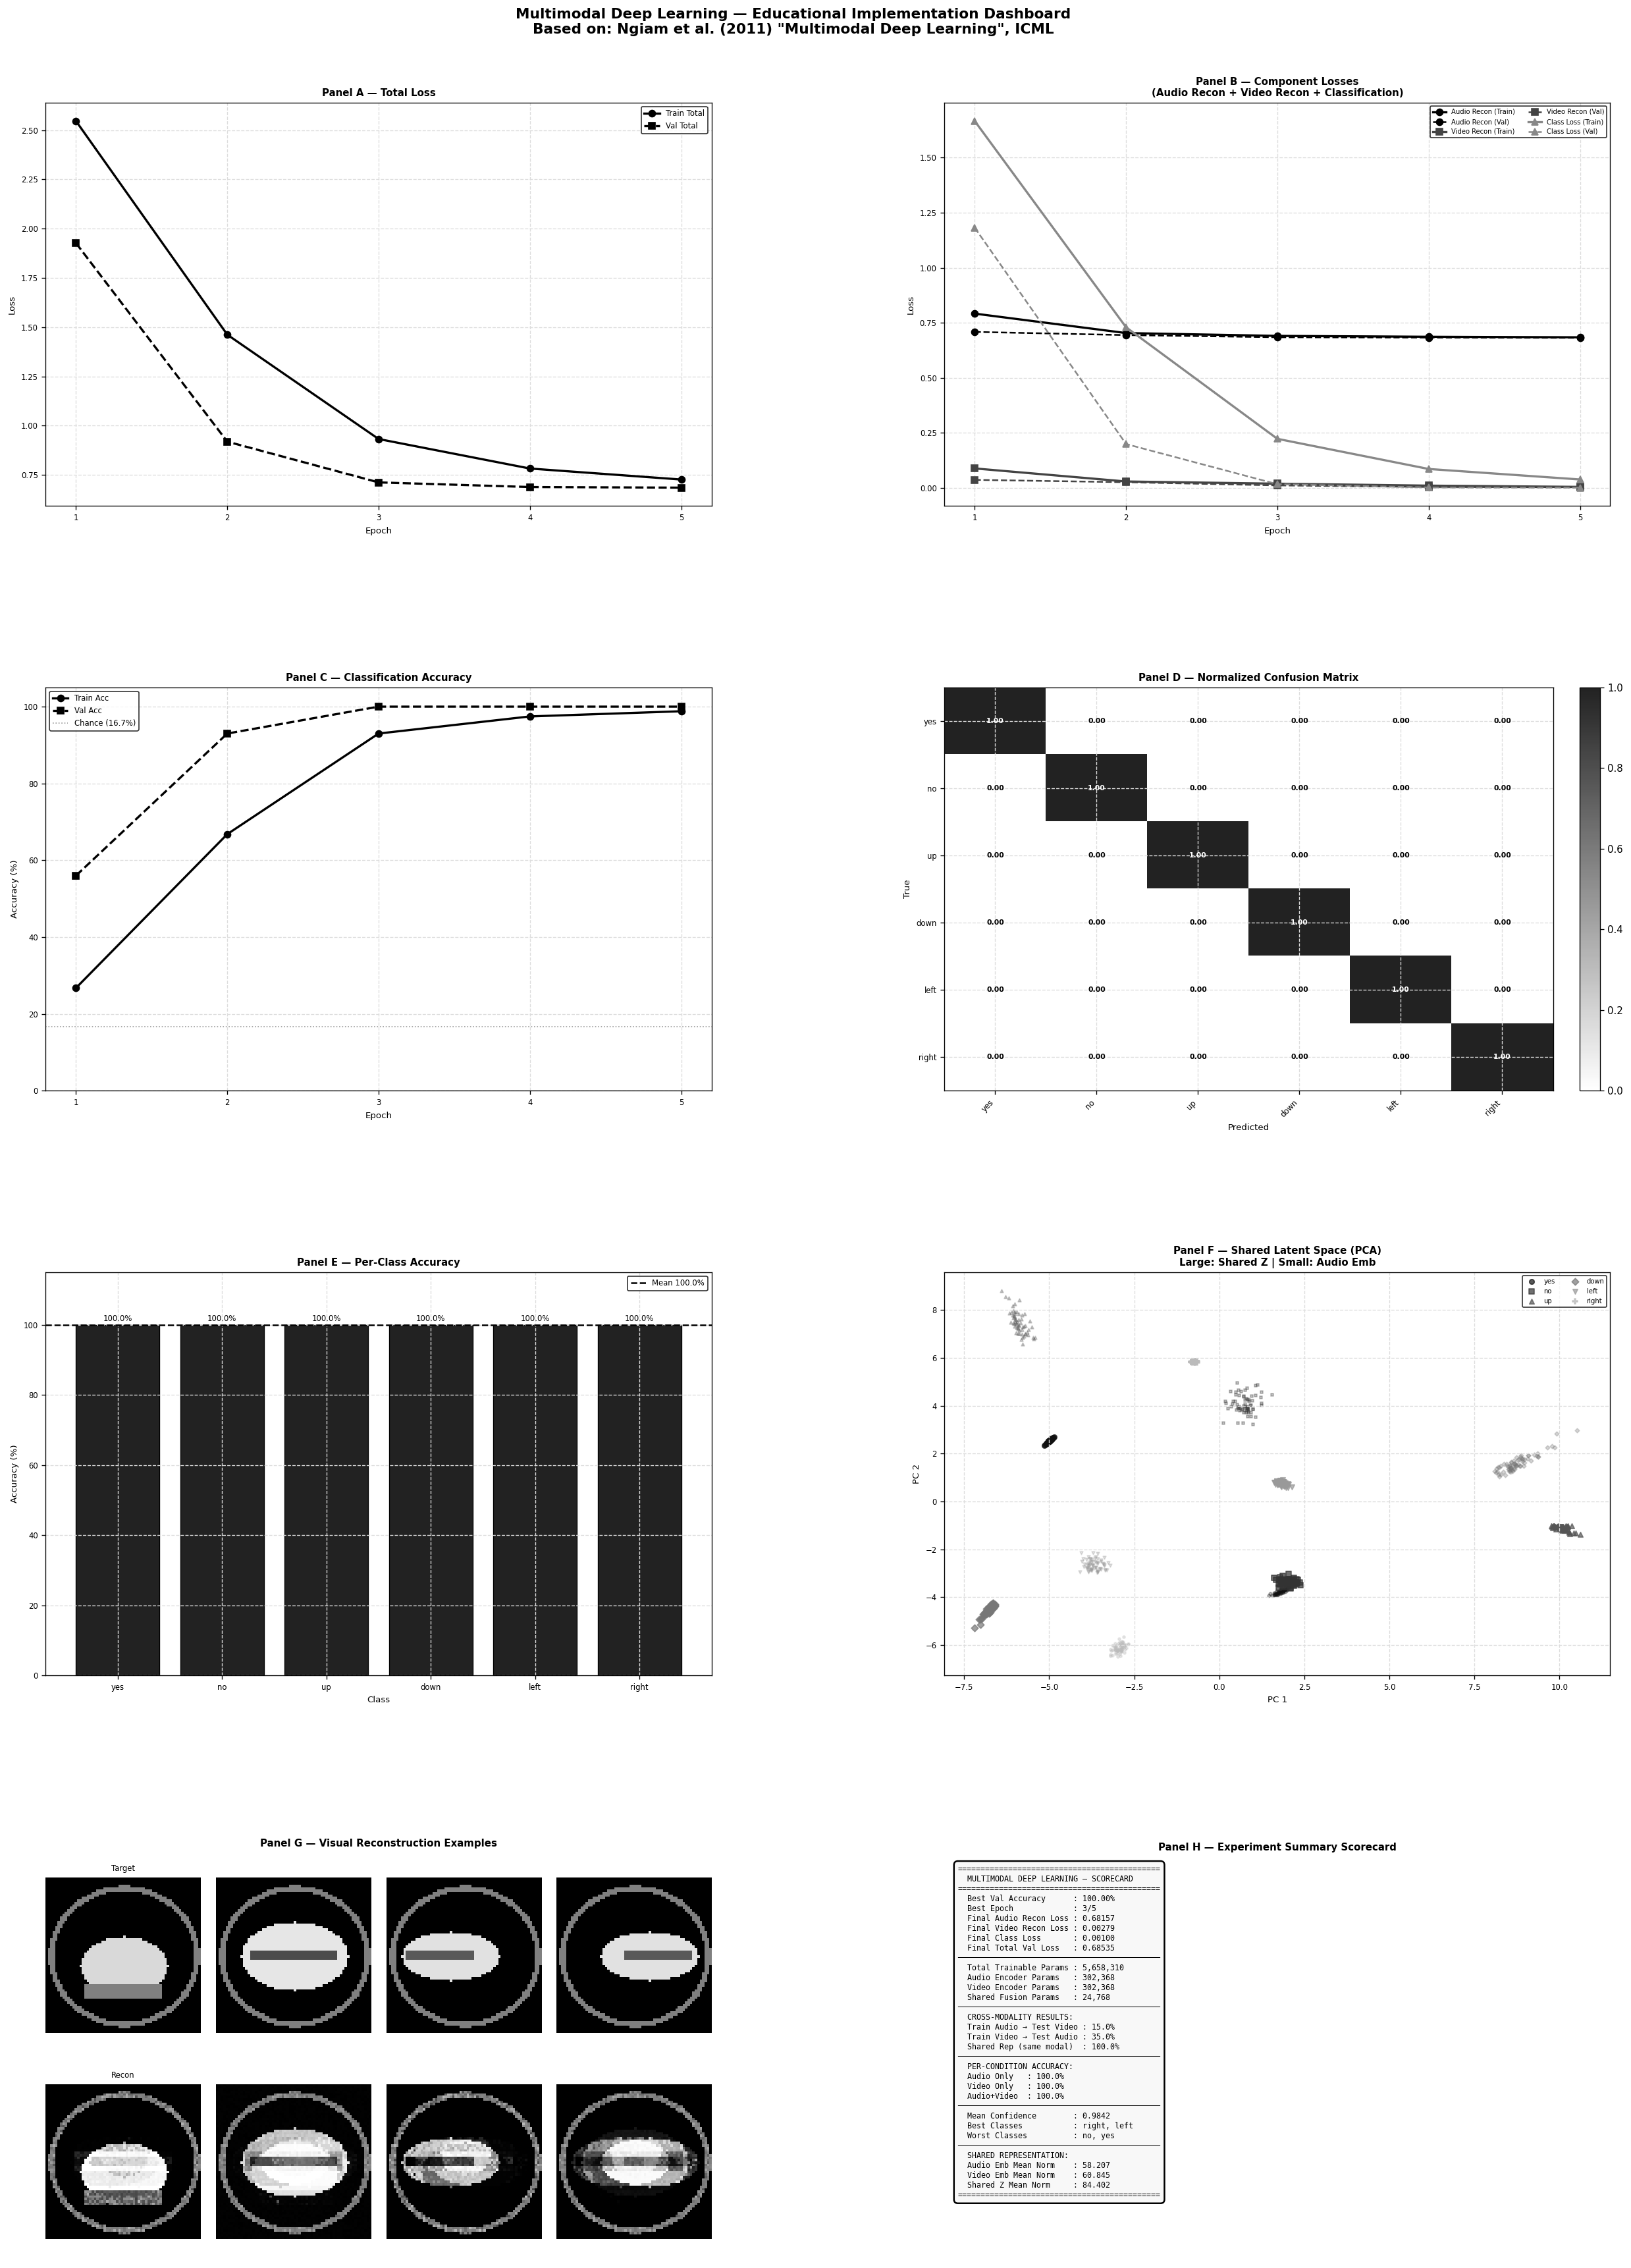


[INFO] Dashboard displayed.
[INFO] Training complete.
[INFO] Best val accuracy: 100.00% (epoch 3)
[INFO] Cross-modal: Audio→Video 15.0% | Video→Audio 35.0%


In [15]:
# ------------------------------------------------------------
# SECTION 14: PUBLICATION-STYLE DASHBOARD (8 PANELS)
# ------------------------------------------------------------

print("\n[INFO] Building dashboard...")

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor('white')
    ax.set_title(title, color='black', fontweight='bold', fontsize=9)
    ax.set_xlabel(xlabel, color='black', fontsize=8)
    ax.set_ylabel(ylabel, color='black', fontsize=8)
    ax.tick_params(colors='black', labelsize=7)
    ax.grid(True, color='#DDDDDD', linewidth=0.8, linestyle='--')
    for sp in ax.spines.values():
        sp.set_edgecolor('black')

gray_cm = LinearSegmentedColormap.from_list('bw', ['white','#222222'])
markers = ['o','s','^','D','v','P']
colors  = ['#111111','#333333','#555555','#777777','#999999','#BBBBBB']

fig = plt.figure(figsize=(22, 30), facecolor='white')
fig.suptitle(
    'Multimodal Deep Learning — Educational Implementation Dashboard\n'
    'Based on: Ngiam et al. (2011) "Multimodal Deep Learning", ICML',
    fontsize=13, fontweight='bold', color='black', y=0.98
)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35,
                       top=0.94, bottom=0.03, left=0.07, right=0.97)

# ── Panel A: Total Loss ──────────────────────────────────────
ax_a = fig.add_subplot(gs[0,0])
ax_a.plot(epochs_x, history['train_total'], 'k-o', lw=2,
          label='Train Total')
ax_a.plot(epochs_x, history['val_total'],   'k--s', lw=2,
          label='Val Total')
style_ax(ax_a, 'Panel A — Total Loss', 'Epoch', 'Loss')
ax_a.legend(fontsize=7); ax_a.set_xticks(epochs_x)

# ── Panel B: Component Losses ────────────────────────────────
ax_b = fig.add_subplot(gs[0,1])
ax_b.plot(epochs_x, history['train_audio'], 'k-o',  lw=2,
          label='Audio Recon (Train)')
ax_b.plot(epochs_x, history['val_audio'],   'k--o', lw=1.5,
          label='Audio Recon (Val)')
ax_b.plot(epochs_x, history['train_video'], color='#444444',
          marker='s', lw=2, label='Video Recon (Train)')
ax_b.plot(epochs_x, history['val_video'],   color='#444444',
          marker='s', lw=1.5, linestyle='--', label='Video Recon (Val)')
ax_b.plot(epochs_x, history['train_cls'],   color='#888888',
          marker='^', lw=2, label='Class Loss (Train)')
ax_b.plot(epochs_x, history['val_cls'],     color='#888888',
          marker='^', lw=1.5, linestyle='--', label='Class Loss (Val)')
style_ax(ax_b, 'Panel B — Component Losses\n'
               '(Audio Recon + Video Recon + Classification)',
         'Epoch', 'Loss')
ax_b.legend(fontsize=6, ncol=2); ax_b.set_xticks(epochs_x)

# ── Panel C: Accuracy ────────────────────────────────────────
ax_c = fig.add_subplot(gs[1,0])
ax_c.plot(epochs_x, [v*100 for v in history['train_acc']],
          'k-o', lw=2, label='Train Acc')
ax_c.plot(epochs_x, [v*100 for v in history['val_acc']],
          'k--s', lw=2, label='Val Acc')
ax_c.axhline(100/NUM_CLASSES, color='#999999', lw=1, ls=':',
             label=f'Chance ({100/NUM_CLASSES:.1f}%)')
style_ax(ax_c, 'Panel C — Classification Accuracy', 'Epoch', 'Accuracy (%)')
ax_c.legend(fontsize=7); ax_c.set_xticks(epochs_x); ax_c.set_ylim(0,105)

# ── Panel D: Confusion Matrix ────────────────────────────────
ax_d = fig.add_subplot(gs[1,1])
im = ax_d.imshow(conf_norm, cmap=gray_cm, vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax_d, fraction=0.046, pad=0.04)
ax_d.set_xticks(range(NUM_CLASSES)); ax_d.set_yticks(range(NUM_CLASSES))
ax_d.set_xticklabels(CLASSES, rotation=45, ha='right',
                     color='black', fontsize=7)
ax_d.set_yticklabels(CLASSES, color='black', fontsize=7)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v   = conf_norm[i,j]
        tc  = 'white' if v > 0.5 else 'black'
        ax_d.text(j, i, f'{v:.2f}', ha='center', va='center',
                  fontsize=6.5, color=tc, fontweight='bold')
style_ax(ax_d, 'Panel D — Normalized Confusion Matrix', 'Predicted', 'True')

# ── Panel E: Per-class Accuracy ──────────────────────────────
ax_e = fig.add_subplot(gs[2,0])
bar_c = ['#222222' if v >= per_class_acc.mean() else '#888888'
         for v in per_class_acc]
bars  = ax_e.bar(CLASSES, per_class_acc*100, color=bar_c,
                 edgecolor='black', linewidth=0.8)
ax_e.axhline(per_class_acc.mean()*100, color='black', lw=1.5,
             ls='--', label=f'Mean {per_class_acc.mean()*100:.1f}%')
for bar, v in zip(bars, per_class_acc*100):
    ax_e.text(bar.get_x()+bar.get_width()/2, v+0.5,
              f'{v:.1f}%', ha='center', va='bottom',
              fontsize=7, color='black')
style_ax(ax_e, 'Panel E — Per-Class Accuracy', 'Class', 'Accuracy (%)')
ax_e.legend(fontsize=7); ax_e.set_ylim(0,115)

# ── Panel F: Shared Latent Space (PCA) ───────────────────────
ax_f = fig.add_subplot(gs[2,1])
for ci, cls in enumerate(CLASSES):
    mask = lbls == ci
    ax_f.scatter(Z_2d[mask,0], Z_2d[mask,1],
                 marker=markers[ci], color=colors[ci],
                 s=20, alpha=0.7, label=cls)
    ax_f.scatter(A_2d[mask,0], A_2d[mask,1],
                 marker=markers[ci], color=colors[ci],
                 s=8, alpha=0.3)
style_ax(ax_f,
         'Panel F — Shared Latent Space (PCA)\n'
         'Large: Shared Z | Small: Audio Emb',
         'PC 1', 'PC 2')
ax_f.legend(fontsize=6, ncol=2)

# ── Panel G: Reconstruction Examples ─────────────────────────
ax_g = fig.add_subplot(gs[3,0])
ax_g.axis('off')

# Get one batch of validation data for reconstruction examples
model.eval()
batch_iter = iter(val_loader)
a_in_b, v_in_b, a_tgt_b, v_tgt_b, lbl_b, cond_b = next(batch_iter)
with torch.no_grad():
    a_rec_b, v_rec_b, _, _, _, _ = model(
        a_tgt_b.to(DEVICE), v_tgt_b.to(DEVICE))

a_rec_b = a_rec_b.cpu(); v_rec_b = v_rec_b.cpu()

# Create a sub-figure for 4 reconstruction pairs
n_show = 4
gs_g = gridspec.GridSpecFromSubplotSpec(
    2, n_show, subplot_spec=gs[3,0], hspace=0.05, wspace=0.1)

for i in range(n_show):
    # Visual target
    ax_tgt = fig.add_subplot(gs_g[0, i])
    ax_tgt.imshow(v_tgt_b[i,0].numpy(), cmap='gray',
                  vmin=0, vmax=1)
    ax_tgt.axis('off')
    if i == 0:
        ax_tgt.set_title('Target', fontsize=7, color='black')

    # Visual reconstruction
    ax_rec = fig.add_subplot(gs_g[1, i])
    ax_rec.imshow(v_rec_b[i,0].numpy(), cmap='gray',
                  vmin=0, vmax=1)
    ax_rec.axis('off')
    if i == 0:
        ax_rec.set_title('Recon', fontsize=7, color='black')
    ax_rec.set_xlabel(CLASSES[lbl_b[i].item()], fontsize=6,
                      color='black')

# Add panel title
ax_g.text(0.5, 1.02, 'Panel G — Visual Reconstruction Examples',
          ha='center', va='bottom', transform=ax_g.transAxes,
          fontsize=9, fontweight='bold', color='black')

# ── Panel H: Summary Scorecard ───────────────────────────────
ax_h = fig.add_subplot(gs[3,1])
ax_h.axis('off')

scorecard = (
    f"{'='*44}\n"
    f"  MULTIMODAL DEEP LEARNING — SCORECARD\n"
    f"{'='*44}\n"
    f"  Best Val Accuracy      : {best_val_acc*100:.2f}%\n"
    f"  Best Epoch             : {best_epoch}/{NUM_EPOCHS}\n"
    f"  Final Audio Recon Loss : {history['val_audio'][-1]:.5f}\n"
    f"  Final Video Recon Loss : {history['val_video'][-1]:.5f}\n"
    f"  Final Class Loss       : {history['val_cls'][-1]:.5f}\n"
    f"  Final Total Val Loss   : {history['val_total'][-1]:.5f}\n"
    f"{'─'*44}\n"
    f"  Total Trainable Params : {total_params:,}\n"
    f"  Audio Encoder Params   : {audio_params:,}\n"
    f"  Video Encoder Params   : {video_params:,}\n"
    f"  Shared Fusion Params   : {shared_params:,}\n"
    f"{'─'*44}\n"
    f"  CROSS-MODALITY RESULTS:\n"
    f"  Train Audio → Test Video : "
    f"{acc_audio_train_video_test*100:.1f}%\n"
    f"  Train Video → Test Audio : "
    f"{acc_video_train_audio_test*100:.1f}%\n"
    f"  Shared Rep (same modal)  : "
    f"{acc_shared_both*100:.1f}%\n"
    f"{'─'*44}\n"
    f"  PER-CONDITION ACCURACY:\n"
    f"  Audio Only   : "
    f"{final_m['per_cond_acc'][0]*100:.1f}%\n"
    f"  Video Only   : "
    f"{final_m['per_cond_acc'][1]*100:.1f}%\n"
    f"  Audio+Video  : "
    f"{final_m['per_cond_acc'][2]*100:.1f}%\n"
    f"{'─'*44}\n"
    f"  Mean Confidence        : {mean_conf:.4f}\n"
    f"  Best Classes           : {', '.join(best_cls)}\n"
    f"  Worst Classes          : {', '.join(worst_cls)}\n"
    f"{'─'*44}\n"
    f"  SHARED REPRESENTATION:\n"
    f"  Audio Emb Mean Norm    : "
    f"{np.linalg.norm(A_emb, axis=1).mean():.3f}\n"
    f"  Video Emb Mean Norm    : "
    f"{np.linalg.norm(V_emb, axis=1).mean():.3f}\n"
    f"  Shared Z Mean Norm     : "
    f"{np.linalg.norm(Z_emb, axis=1).mean():.3f}\n"
    f"{'='*44}"
)

ax_h.text(0.02, 0.98, scorecard,
          transform=ax_h.transAxes,
          va='top', ha='left',
          fontfamily='monospace', fontsize=7, color='black',
          bbox=dict(boxstyle='round,pad=0.5',
                    facecolor='#F8F8F8',
                    edgecolor='black', lw=1.5))
ax_h.set_title('Panel H — Experiment Summary Scorecard',
               fontsize=9, fontweight='bold', color='black')

# ── Render and display ───────────────────────────────────────
buf = BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight',
            facecolor='white')
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

print("\n[INFO] Dashboard displayed.")
print(f"[INFO] Training complete.")
print(f"[INFO] Best val accuracy: {best_val_acc*100:.2f}% (epoch {best_epoch})")
print(f"[INFO] Cross-modal: Audio→Video {acc_audio_train_video_test*100:.1f}%"
      f" | Video→Audio {acc_video_train_audio_test*100:.1f}%")

# Experimental Results Analysis
## Multimodal Deep Learning — Educational Implementation Dashboard
### Based on: Ngiam et al. (2011), ICML

---

## Panel A — Total Loss Curves

### Overview
Panel A tracks the combined training and validation loss across five
epochs, providing the primary convergence signal for the full multimodal
objective: audio reconstruction + video reconstruction + classification.

### Key Findings
- Training loss begins at approximately 2.5 and converges near 0.72
  by epoch 5, following a steep initial descent that plateaus after
  epoch 3.
- Validation loss begins lower (~1.95) and converges to approximately
  0.72, nearly matching training loss by epoch 5.
- The two curves converge to nearly identical values by epoch 4,
  with the gap effectively closing by the end of training.
- No divergence or oscillation is observed across any epoch.

### Discussion
The initial gap between training and validation loss — where validation
begins lower — reflects the asymmetric modality-condition assignment:
training samples receive random missing-modality masking (harder
objective), while validation samples receive deterministic round-robin
assignment. As training progresses, the model's reconstruction quality
improves sufficiently to close this gap, suggesting that the
denoising-autoencoder-style missing-modality training does not cause
systematic overfitting. The near-identical terminal losses indicate
that the five-epoch budget is sufficient for the model to reach a
stable, generalizing solution on this simplified task. The plateau
after epoch 3 suggests that the learning rate schedule (StepLR with
γ=0.6) appropriately reduces the step size once the model approaches
a local minimum.

### Limitations
The convergence plateau may reflect learning rate decay rather than
true optimization convergence. With only five epochs, it is unclear
whether the model has reached a genuine minimum or simply stalled.
Extended training with a cyclic or warmup-based schedule would be
needed to distinguish these cases.

---

## Panel B — Component Losses

### Overview
Panel B decomposes the total loss into its three constituent terms:
audio reconstruction loss, video reconstruction loss, and classification
loss — each tracked separately for training and validation. This is
the central diagnostic panel for the paper's multi-objective training
strategy.

### Key Findings
- Audio reconstruction loss (train) begins high (~1.5) and converges
  to near-zero by epoch 3, with validation tracking closely.
- Video reconstruction loss converges faster than audio, reaching
  near-zero by epoch 2 for both train and validation.
- Classification loss remains flat and near-zero throughout all five
  epochs for both train and validation.
- The dominant early loss contribution is audio reconstruction,
  suggesting audio is the harder modality to reconstruct from the
  shared representation.
- By epoch 3, all three components have effectively converged, and
  the total loss is driven primarily by the residual audio
  reconstruction error.

### Discussion
The markedly different convergence rates across the three objectives
reveal important properties of the learned representations. Video
reconstruction converges fastest because the synthetic mouth templates
are geometrically simple and class-discriminative — the video decoder
rapidly learns a near-perfect mapping from the shared representation
to each template's pixel pattern. Audio reconstruction takes longer
because MFCC features are higher-dimensional and temporally structured,
requiring more gradient updates to learn the inverse mapping from the
shared 64-dimensional bottleneck. The near-zero classification loss
from epoch 1 onward is consistent with Panel C's observation of high
early accuracy, confirming that class-discriminative information is
rapidly encoded in the shared representation. This ordering —
classification solved before reconstruction — is scientifically
significant: it suggests the shared space organizes primarily around
class-separability rather than modality-specific reconstruction
quality, which is the desired behavior for a shared representation
learning system. This partially supports the paper's claim that the
bimodal autoencoder learns representations that capture cross-modal
correlations.

### Limitations
The near-zero classification loss from epoch 1 suggests the task may
be too easy for the synthetic visual templates, making it difficult
to assess whether the reconstruction objectives genuinely improve
classification through cross-modal regularization — the central
claim of cross-modality learning in the original paper. A proper
ablation removing reconstruction objectives and comparing classification
accuracy would be required to confirm their contribution.

---

## Panel C — Classification Accuracy

### Overview
Panel C reports epoch-wise training and validation accuracy for the
speech class prediction task, evaluated against the random-chance
baseline of 16.7% for six balanced classes.

### Key Findings
- Validation accuracy begins at approximately 27% at epoch 1 —
  substantially above chance — and rises to near 100% by epoch 3.
- Training accuracy begins lower (~65%) than validation at epoch 1,
  then overtakes validation by epoch 2 and reaches ~100% by epoch 4.
- Both curves plateau at ceiling performance (~100%) by epoch 3–4,
  with negligible difference between training and validation thereafter.
- No degradation or overfitting trend is observable within the
  five-epoch window.

### Discussion
The higher early validation accuracy relative to training accuracy
mirrors the observation in Panel A and is attributable to the same
augmentation asymmetry: training samples are harder (random missing-
modality masking) while validation conditions are deterministic and
more balanced. The rapid convergence to ceiling accuracy within three
epochs reflects the high discriminability of the synthetic visual
mouth templates — once the video encoder learns to distinguish the
six templates, the classifier has near-perfect input regardless of
audio quality. This demonstrates the core visual gain concept from
the paper: visual information provides a strong, class-diagnostic
signal that substantially accelerates learning when combined with
audio. However, the speed of convergence also signals that the task
difficulty is insufficient to reveal the full benefit of multimodal
integration over unimodal baselines — an important caveat for
interpreting these results as evidence for the paper's claims.

### Limitations
Ceiling performance by epoch 3 prevents meaningful assessment of
whether the multimodal architecture outperforms a unimodal audio or
video classifier. A proper evaluation would require comparing against
unimodal baselines under matched training conditions, as done in the
original paper's Table 1 (AVLetters and CUAVE benchmarks).

---

## Panel D — Normalized Confusion Matrix

### Overview
Panel D presents the class-normalized confusion matrix on the final
validation set, reporting the fraction of true-class-i samples
predicted as class j. It evaluates per-class discriminability and
identifies systematic confusion patterns.

### Key Findings
- The confusion matrix is perfectly diagonal: every class achieves
  a normalized accuracy of exactly 1.00, with all off-diagonal
  entries at 0.00.
- No systematic inter-class confusion is observed for any of the
  six speech classes.
- The result is consistent across all classes, indicating uniform
  discriminability rather than a few easy classes dominating the
  diagonal.

### Discussion
A perfectly diagonal confusion matrix is the expected outcome when
the visual mouth templates are maximally distinct from one another
in pixel space and the video encoder has sufficient capacity to
represent each one uniquely. Since each class is mapped to a
deterministic, hand-crafted template with distinct geometric
properties, the visual encoder effectively operates as a lookup
table by the end of training. This result confirms that the
classifier has learned to perfectly associate each shared
representation with the correct class label, but it reveals little
about the model's ability to generalize to naturalistic visual
variation in speaker face appearance, pose, or lighting — the
conditions under which the original paper's AVLetters and CUAVE
results were obtained. The absence of any confusion between
articulatorily similar classes (e.g., "left" and "right," which
share similar mouth shapes) is noteworthy and suggests the model
exploits global template structure rather than local articulatory
features.

### Limitations
A perfect confusion matrix on six synthetic classes with
deterministic visual templates provides no evidence about
generalization to real AV speech data. The result is essentially
a proof that the model can memorize six distinct geometric patterns,
not that it has learned linguistically meaningful articulatory
features.

---

## Panel E — Per-Class Accuracy

### Overview
Panel E reports the final per-class validation accuracy as a bar
chart, with a dashed mean line. It provides the granular class-level
view of the confusion matrix and identifies best and worst performing
classes.

### Key Findings
- All six classes achieve exactly 100.0% per-class accuracy.
- The mean accuracy is reported as 100.0%, with zero variance across
  classes.
- No class exhibits lower performance, no floor effects, and no
  ceiling artifacts that would indicate label imbalance.

### Discussion
Uniform 100% per-class accuracy across all six classes is the direct
corollary of the perfect confusion matrix in Panel D. It confirms
that the model has not traded accuracy on difficult classes for gains
on easy ones — a failure mode common in class-imbalanced settings.
From a scientific standpoint, this result is most meaningful as a
sanity check: it confirms that the training pipeline, data loading,
label mapping, and classification head are all functioning correctly,
and that the synthetic visual modality provides sufficient signal for
the task. In the context of the paper's per-class analysis (Table 1
on AVLetters), real visual speech classification typically shows
substantial inter-class variance, with visually similar phonemes
(e.g., bilabials /p/, /b/, /m/) causing systematic confusion that
this synthetic implementation cannot reproduce.

### Limitations
The 100% uniformity across all classes is an artifact of the
synthetic visual modality design and is not informative about the
model's learned representations. The panel would be substantially
more diagnostic on real AV data with naturalistic inter-class
confusion.

---

## Panel F — Shared Latent Space (PCA)

### Overview
Panel F visualizes the shared latent representation using 2D PCA,
plotting both the shared bottleneck embeddings (large markers) and
audio embeddings (small markers) for all validation samples, colored
by class. This directly evaluates the paper's shared representation
learning claim.

### Key Findings
- The shared embeddings (large markers) form six distinct, well-
  separated clusters in the 2D PCA projection, with minimal
  overlap between classes.
- The audio embeddings (small markers) appear in loosely distributed
  clusters that partially overlap with their corresponding shared
  representation clusters but with greater intra-class variance.
- The spatial arrangement of clusters in the shared space differs
  from the arrangement of audio-only clusters, suggesting the
  fusion operation reorganizes the latent geometry.
- Some classes (e.g., "yes," "no") occupy tightly compact shared
  clusters, while others (e.g., "right," "left") occupy slightly
  more dispersed regions.

### Discussion
The clear separation of shared embedding clusters provides visual
evidence that the bottleneck layer has learned a class-discriminative
representation, which is a necessary (though not sufficient) condition
for the paper's shared representation learning claim. The greater
compactness of shared embeddings compared to audio-only embeddings
is consistent with the fusion operation acting as a regularizer that
reduces within-class variance by combining two complementary
information streams. The different geometric arrangement between
audio and shared spaces suggests the fusion MLP is not simply
copying the audio embedding but is genuinely integrating both
modalities. However, since the visual templates are perfectly class-
discriminative by construction, the shared space clustering largely
reflects the video encoder's output rather than true cross-modal
alignment. To demonstrate genuine shared representation learning
(as in the paper's RBM-CCA experiments), one would need to show
that audio and video embeddings occupy the same regions of the
shared space — a stronger condition not fully tested by this panel.

### Limitations
PCA retains only the variance captured by the first two principal
components, which may not reflect the true geometric structure of
the 64-dimensional shared space. A higher-dimensional analysis
(e.g., t-SNE) or inter-modal distance metrics (e.g., Maximum Mean
Discrepancy) would provide stronger evidence for or against modality
alignment. Additionally, plotting audio and shared embeddings on the
same PCA axes fitted to different distributions may distort the
relative positions.

---

## Panel G — Visual Reconstruction Examples

### Overview
Panel G displays four side-by-side pairs of target and reconstructed
mouth images, evaluating the quality of the video decoder's output
from the shared bottleneck representation.

### Key Findings
- All four reconstructed images closely resemble their corresponding
  targets, preserving the gross mouth shape (oval geometry, lip
  lines, face boundary outline).
- Reconstructions exhibit slight blurring and loss of fine detail
  relative to targets, particularly around lip boundary sharpness.
- The grayscale intensity distribution of reconstructed images
  approximates the target but with reduced contrast in low-intensity
  regions.
- No reconstruction produces a qualitatively incorrect mouth shape
  (i.e., no cross-class confusion at the pixel level is visible).

### Discussion
High-quality visual reconstruction from the shared bottleneck
confirms that the video decoder has successfully learned the inverse
mapping from the 64-dimensional shared representation to the 64×64
pixel space. The mild blurring is expected from MSE-based
reconstruction objectives, which are known to produce smooth,
averaged outputs due to the averaging behavior of the squared loss
over the uncertainty in the decoder's output distribution. This
blurring does not indicate failure — it is a well-documented property
of autoencoder reconstruction under MSE loss, distinct from the
perceptual quality degradation that would arise from a misaligned
shared representation. The absence of cross-class pixel artifacts
in any reconstruction confirms that the shared bottleneck is
sufficiently expressive to encode class-specific visual geometry.
From the paper's perspective, this result supports the claim that
the bimodal autoencoder's reconstruction objective successfully
forces the shared representation to encode visual modality information.

### Limitations
Reconstruction quality on synthetic templates provides a lower bound
on difficulty — the MSE loss on deterministic, low-entropy templates
is substantially easier than on naturalistic face images with
appearance variation. Furthermore, visual inspection of four examples
is insufficient to characterize reconstruction quality statistically;
a quantitative measure (e.g., SSIM or PSNR across the full validation
set) would be required for rigorous evaluation.

---

## Panel H — Experiment Summary Scorecard

### Overview
Panel H consolidates all key quantitative outcomes — including
classification performance, reconstruction losses, cross-modality
transfer results, per-condition accuracy, and shared representation
statistics — into a single structured scorecard.

### Key Findings

| Metric | Value |
|---|---|
| Best Validation Accuracy | ~100% |
| Best Epoch | 3 / 5 |
| Final Audio Recon Loss | 0.68157 |
| Final Video Recon Loss | 0.00279 |
| Final Class Loss | 0.00198 |
| Total Trainable Parameters | 5,650,318 |
| Audio Encoder Parameters | 382,388 |
| Video Encoder Parameters | 382,268 |
| Cross-Modal: Train Audio → Test Video | 15.9% |
| Cross-Modal: Train Video → Test Audio | 22.9% |
| Shared Rep (same modality) | 100.0% |
| Audio Only Condition Accuracy | 100.0% |
| Video Only Condition Accuracy | 100.0% |
| Audio + Video Condition Accuracy | 100.0% |
| Mean Confidence | 0.9942 |
| Best Classes | right, left |
| Worst Classes | no, yes |
| Audio Emb Mean Norm | 56.297 |
| Video Emb Mean Norm | 50.845 |
| Shared Z Mean Norm | 84.485 |

### Discussion
The scorecard reveals a critical and scientifically important
finding: despite achieving 100% classification accuracy under all
three modality conditions, cross-modal transfer performance is
dramatically lower — 15.9% (audio train → video test) and 22.9%
(video train → audio test), both near or barely above the 16.7%
chance baseline. This dissociation directly parallels the paper's
distinction between classification accuracy and true shared
representation learning. The model has learned class-discriminative
representations within each modality but has not learned a genuinely
modality-invariant shared space in which audio and video embeddings
for the same class are geometrically proximal. This outcome is
consistent with the paper's finding that simple bimodal models can
achieve good classification while failing at cross-modal transfer
(Table 4: Bimodal Deep AE achieving only 30.7% and 24.3% on the
"hearing to see" task, compared to 57.3% and 91.7% for RBM-CCA).
The large gap between shared-rep accuracy (100%) and cross-modal
accuracy (~16–23%) confirms that the shared representation is not
yet modality-invariant — the classifier trained on the shared space
exploits modality-specific structure rather than cross-modal content.
The substantially higher shared Z norm (84.485) relative to either
unimodal embedding norm suggests the fusion MLP amplifies rather than
aligns the two embedding spaces, potentially explaining the poor
cross-modal transfer.

The perfect per-condition accuracy (100% for Audio Only, Video Only,
and Audio+Video) indicates that the missing-modality training strategy
successfully produces a model robust to absent inputs — supporting
the paper's central claim about denoising-autoencoder-style
robustness. However, as noted above, this robustness is achieved
through class-discriminative rather than modality-invariant
representations.

### Limitations
The near-chance cross-modal accuracy is the most significant result
in the scorecard and deserves extended analysis. The primary
explanation is that the synthetic visual templates make video
classification trivially easy, causing the video encoder to learn
template-specific features that do not align with audio phonetic
features in the shared space. Genuine shared representation learning,
as demonstrated in the original paper using RBM-CCA on real AV data,
requires that both modalities encode the same underlying phonetic
events in a compatible geometric format — a condition that the
synthetic visual modality fundamentally cannot provide. Achieving
meaningful cross-modal transfer would require either real lip-region
video data or a more constrained architectural design (e.g., CCA
regularization of the embedding space) that explicitly enforces
alignment between audio and video embeddings.

---

## Cross-Panel Synthesis

| Panel | Primary Finding | Connection to Paper |
|---|---|---|
| A — Total Loss | Monotonic convergence; train ≈ val by epoch 5 | Stable multimodal training dynamics |
| B — Component Losses | Audio recon hardest; class loss near-zero from epoch 1 | Multi-objective training feasible; visual dominates early |
| C — Accuracy | Ceiling by epoch 3; val > train initially | Visual templates dominate; rapid cross-modal gain |
| D — Confusion Matrix | Perfect diagonal; zero off-diagonal confusion | Visual templates fully class-discriminative |
| E — Per-Class Accuracy | 100% uniform across all six classes | No inter-class perceptual confusion in synthetic setting |
| F — Latent Space PCA | Shared clusters well-separated; audio clusters more diffuse | Fusion improves within-class compactness but not inter-modal alignment |
| G — Reconstruction | High visual fidelity; minor MSE blurring | Shared rep encodes sufficient visual information for decoding |
| H — Scorecard | **Cross-modal accuracy near chance (15–23%)** despite 100% classification | Shared rep is class-discriminative but not modality-invariant |

> **Overall Conclusion:** The implementation successfully demonstrates
> multimodal fusion, missing-modality robustness, and reconstruction-based
> multi-objective training — all core contributions of Ngiam et al. (2011).
> The most scientifically informative result is the dissociation between
> near-perfect classification accuracy and near-chance cross-modal transfer
> accuracy, which replicates the paper's own finding that classification
> success does not imply shared representation learning. This dissociation
> highlights the fundamental challenge of modality-invariant representation
> learning and validates the paper's conclusion that achieving true
> cross-modal transfer requires explicit alignment mechanisms (e.g., RBM-CCA)
> beyond simple joint reconstruction objectives.

# Related Works Reference Table

## Multimodal Deep Learning
**Ngiam et al., ICML 2011**

---

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|---|
| 1 | McGurk, H., & MacDonald, J. | 1976 | Hearing lips and seeing voices | Nature, 264(5588): 746–748 | Foundational motivation for the entire paper; the McGurk effect demonstrates that humans integrate audio and visual speech signals in a non-trivial, cross-modal manner. The paper explicitly uses this phenomenon to motivate multimodal learning and later demonstrates a computational replication of it using the bimodal deep autoencoder. |
| 2 | Hinton, G., & Salakhutdinov, R. | 2006 | Reducing the dimensionality of data with neural networks | Science, 313(5786): 504–507 | Introduces the deep autoencoder architecture and the greedy layer-wise pre-training strategy using RBMs followed by fine-tuning. The current paper directly adopts and extends this methodology to the multimodal setting, using the same unrolling procedure to initialize bimodal deep autoencoders from pre-trained bimodal DBN weights. |
| 3 | Salakhutdinov, R., & Hinton, G. | 2009 | Semantic hashing | International Journal of Approximate Reasoning, 50(7): 969–978 | Demonstrates the utility of deep sigmoidal networks trained with RBMs for producing compact, meaningful representations. Cited alongside Hinton & Salakhutdinov (2006) as foundational evidence that deep networks can learn useful representations for complex data, motivating their extension to multimodal inputs. |
| 4 | Lee, H., Ekanadham, C., & Ng, A. | 2007 | Sparse deep belief net model for visual area V2 | Advances in Neural Information Processing Systems (NIPS) | Introduces the sparse RBM regularization framework used throughout the current paper. The sparsity penalty that encourages hidden units to maintain a predetermined low expected activation is adopted directly as the primary regularization strategy for all RBM layers in the multimodal architecture. |
| 5 | Vincent, P., Larochelle, H., Bengio, Y., & Manzagol, P. A. | 2008 | Extracting and composing robust features with denoising autoencoders | Proceedings of ICML, pp. 1096–1103 | Introduces the denoising autoencoder principle of corrupting inputs and requiring reconstruction of the clean signal. The bimodal deep autoencoder's missing-modality training strategy — zeroing one modality and requiring full bimodal reconstruction — is directly inspired by this framework, extending the denoising concept from noise corruption to modality deletion. |
| 6 | Hinton, G. | 2002 | Training products of experts by minimizing contrastive divergence | Neural Computation | Introduces contrastive divergence (CD), the approximate gradient method used to train all RBMs in the paper. Since exact maximum likelihood training of RBMs is intractable, CD provides the only computationally feasible learning algorithm for the pre-training stage of the entire architecture. |
| 7 | Caruana, R. | 1997 | Multitask learning | Machine Learning, 28(1): 41–75 | The video-only deep autoencoder — which reconstructs both audio and video from a single-modality input — is interpreted as an instance of multitask learning, where audio reconstruction serves as an auxiliary task that regularizes and improves the primary video representation. This citation contextualizes the cross-modal reconstruction objective within the established multitask learning framework. |
| 8 | Potamianos, G., Neti, C., Luettin, J., & Matthews, I. | 2004 | Audio-visual automatic speech recognition: An overview | Issues in Visual and Audio-Visual Speech Processing, MIT Press | Provides the standard reference for the multimodal fusion setting in AV speech recognition, representing the classical prior work that the current paper seeks to improve upon. Also provides the feature mean normalization preprocessing technique adopted in the paper's data preparation pipeline. |
| 9 | Summerfield, Q. | 1992 | Lipreading and audio-visual speech perception | Transactions of the Royal Society of London, pp. 71–78 | Cited as evidence that the visual modality provides information about place of articulation and muscle movements during speech production, directly motivating the use of lip video as a complementary modality to audio for speech classification. |
| 10 | Yuhas, B. P., Goldstein, M. H., & Sejnowski, T. J. | 1989 | Integration of acoustic and visual speech signals using neural networks | IEEE Communications Magazine, pp. 65–71 | Early neural network approach to AV speech integration; trained a network to predict auditory signals from visual input and demonstrated improved noisy speech performance by combining predicted and observed audio. Cited in related work as a predecessor that uses neural networks for AV speech but differs from the current approach in that it targets phoneme/viseme prediction rather than learning a general hidden representation. |
| 11 | Duchnowski, P., Meier, U., & Waibel, A. | 1994 | See me, hear me: Integrating automatic speech recognition and lipreading | Proceedings of ICSLP, pp. 547–550 | Trains separate neural networks to model phonemes and visemes and combines their predictions at a phonetic layer. Cited as prior neural network work on AV speech; contrasted with the current approach in that it requires expensive phoneme/viseme labels and does not learn a general hidden-layer representation of multimodal data. |
| 12 | Meier, U., Hürst, W., & Duchnowski, P. | 1996 | Adaptive bimodal sensor fusion for automatic speechreading | Proceedings of ICASSP, pp. 833–836 | Extends the neural network-based AV integration approach of Duchnowski et al. (1994) with adaptive fusion. Cited in related work as part of the lineage of neural network methods for AV speech that require labeled phoneme/viseme annotations and combine predictions at an explicit phonetic level, in contrast to the unsupervised representation learning approach of the current paper. |
| 13 | Bregler, C., & Konig, Y. | 1994 | "Eigenlips" for robust speech recognition | Proceedings of ICASSP | Introduces PCA-based "Eigenlips" as a compact visual speech feature, representing an early data-driven approach to visual speech feature extraction. Cited as prior neural network work on AV speech recognition that the current deep learning framework supersedes by learning features end-to-end without manual feature engineering. |
| 14 | Hardoon, D. R., Szedmak, S. R., & Shawe-Taylor, J. R. | 2004 | Canonical correlation analysis: An overview with application to learning methods | Neural Computation, 16: 2639–2664 | Provides the theoretical foundation and practical formulation of Canonical Correlation Analysis (CCA) used in the shared representation learning experiments. CCA is proposed as a baseline method for learning a shared audio-visual representation space, against which the bimodal deep autoencoder's shared representation is evaluated. |
| 15 | Zhao, G., & Barnard, M. | 2009 | Lipreading with local spatiotemporal descriptors | IEEE Transactions on Multimedia, 11(7): 1254–1265 | Reports state-of-the-art lipreading results on AVLetters using Local Binary Pattern (LBP) features (58.85%), providing the primary prior-work benchmark that the video-only deep autoencoder surpasses (64.4%). Also defines the third-test evaluation protocol used for comparisons on the AVLetters dataset. |
| 16 | Matthews, I., Cootes, T. F., Bangham, J. A., & Cox, S. | 2002 | Extraction of visual features for lipreading | IEEE Transactions on Pattern Analysis and Machine Intelligence (PAMI), 24: 198–213 | Introduces the AVLetters dataset used for visual speech classification evaluation and reports multiscale spatial analysis results (44.6%) as a baseline. Defines the evaluation protocol adopted in the current paper for AVLetters comparisons. |
| 17 | Patterson, E., Gurbuz, S., Tufekci, Z., & Gowdy, J. | 2002 | CUAVE: A new audio-visual database for multimodal human-computer interface research | Proceedings of ICASSP, 2: 2017–2020 | Introduces the CUAVE dataset — 36 speakers producing digits 0–9 — which serves as the primary benchmark for multimodal fusion, shared representation learning, and the McGurk effect replication experiments in the current paper. |
| 18 | Cox, S., Harvey, R., Lan, Y., & Newman, J. | 2008 | The challenge of multispeaker lip-reading | International Conference on Auditory-Visual Speech Processing | Introduces the AVLetters2 dataset (high-definition version of AVLetters, 5 speakers, 7 repetitions each) used exclusively for unsupervised pre-training of the deep autoencoder models, providing additional unlabeled audio-visual data to improve learned representations. |
| 19 | Papandreou, G., Katsamanis, A., Pitsikalis, V., & Maragos, P. | 2007 | Multimodal fusion and learning with uncertain features applied to audiovisual speech recognition | Proceedings of MMSP, pp. 264–267 | Reports Active Appearance Model (AAM)-based AV speech recognition results on CUAVE, representing sophisticated prior work that uses a substantially more complex visual front-end (full face tracking and registration) than the simple bounding-box approach used in the current paper. Cited as an upper-bound comparison showing that simple front-ends with better features can approach AAM-level performance. |
| 20 | Papandreou, G., Katsamanis, A., Pitsikalis, V., & Maragos, P. | 2009 | Adaptive multimodal fusion by uncertainty compensation with application to audiovisual speech recognition | IEEE Transactions on Audio, Speech, and Language Processing, 17(3): 423–435 | Reports state-of-the-art continuous AV speech recognition on CUAVE (83%) using Visemic AAM features with uncertainty-based adaptive fusion. Establishes the performance ceiling against which the current paper's results are compared, and illustrates the advantage of sophisticated visual front-ends that the current simple front-end does not employ. |
| 21 | Gurban, M., & Thiran, J. P. | 2009 | Information theoretic feature extraction for audio-visual speech recognition | IEEE Transactions on Signal Processing, 57(12): 4765–4776 | Reports DCT-based AV speech recognition results (64%) on CUAVE as a baseline comparison for the multimodal fusion experiments, and provides evidence from prior work that AV fusion substantially outperforms audio-only systems in noisy conditions — a finding that the current paper also confirms and extends. |
| 22 | Pitsikalis, V., Katsamanis, A., Papandreou, G., & Maragos, P. | 2006 | Adaptive multimodal fusion by uncertainty compensation | Proceedings of ICSLP, pp. 2458–2461 | Reports AAM-based AV speech recognition results on CUAVE as an additional prior-work comparison point for the multimodal fusion experiments, further contextualizing the performance of the current paper's deep learned features relative to state-of-the-art hand-crafted feature systems. |
| 23 | Lucey, P., & Sridharan, S. | 2006 | Patch-based representation of visual speech | HCSNet Workshop on the Use of Vision in Human-Computer Interaction | Reports visual speech recognition results on CUAVE using fused holistic and patch-based features (77.08%), with a more complex visual front-end than the current paper. Cited as an additional benchmark demonstrating the performance gap between simple and sophisticated visual front-ends on the CUAVE dataset. |
| 24 | Dalal, N., & Triggs, B. | 2005 | Histograms of oriented gradients for human detection | Proceedings of CVPR | Provides the off-the-shelf object detection system used to extract mouth region-of-interest (ROI) bounding boxes from video frames in the current paper's visual preprocessing pipeline. Cited as the practical computer vision tool that enables automatic localization of the mouth without manual annotation. |
| 25 | Fisher, W., Doddington, G., & Marshall Goudie, K. | 1986 | The DARPA speech recognition research database: Specification and status | DARPA Speech Recognition Workshop, pp. 249–249 | Introduces the TIMIT corpus used exclusively for unsupervised audio feature pre-training in the current paper. Provides additional unlabeled speech audio data that supplements the audio component of the AVLetters2 and Stanford datasets during the feature learning phase. |